# 01 — Análise Exploratória de Dados: Modelo de Aplicação

## Contexto

Este notebook realiza a Análise Exploratória de Dados (EDA) voltada ao **Modelo de Aplicação**,
cujo objetivo é estimar a probabilidade de inadimplência de um cliente **no momento do seu cadastro** na plataforma da Praso.

As variáveis disponíveis para este modelo são exclusivamente aquelas acessíveis **antes da primeira compra**:
dados públicos da Receita Federal, informações de crédito da Serasa e dados de plataformas digitais (iFood e Google Maps).

## Objetivo da EDA

- Compreender a estrutura e a saúde dos dados
- Identificar missing values, inconsistências e variáveis problemáticas
- Analisar a distribuição da variável-alvo (`inadimplente`)
- Investigar relações entre as features e a inadimplência
- Levantar hipóteses e decisões que guiarão o pré-processamento e a modelagem

In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

# Seed global (reprodutibilidade)
SEED = 42

# Carregamento dos dados
df = pd.read_csv("/content/drive/MyDrive/ML_Inadimplencia_Praso/data/raw/aplicacao.csv")

# Inspeção inicial
print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas\n")
print("── Primeiras linhas ──")
display(df.head())

print("\n── Tipos de dados ──")
display(df.dtypes.to_frame(name="dtype"))

Shape: 3000 linhas × 19 colunas

── Primeiras linhas ──


,id_cliente,uf,municipio,segmento_cliente,natureza_juridica,fonte_cliente,cnae_codigo,capital_social,idade_cnpj,serasa_contagem_negativacoes,serasa_contagem_protestos,serasa_credores,serasa_socio_tem_negativacao,ifood_contagem_avaliacoes,ifood_faixa_preco,google_maps_avaliacao,google_maps_contagem_avaliacoes,google_maps_tem_website,inadimplente
0,1000732585882,CE,CAUCAIA,Segmento 2,213-5 - Empresário (Individual),Fonte 1,77.49-8-16,"(1500, 2000]","(3000, 4000]",0.0000,0.0000,NaN,0.0000,"(50, 100]",$$,NaN,NaN,NaN,0.0000
1,1001250740869,CE,FORTALEZA,Segmento 10,206-2 - Sociedade Empresária Limitada,Fonte 5,39.87-6-92,"(8000, 10000]","(25, 50]",3.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000
2,1002669165825,CE,CAUCAIA,Segmento 20,213-5 - Empresário (Individual),Fonte 1,53.35-1-24,"(1500, 2000]","(3000, 4000]",5.0000,0.0000,"Financeiro, Comércio, Tecnologia",1.0000,NaN,NaN,NaN,NaN,NaN,0.0000
3,1003899664289,CE,FORTALEZA,Segmento 16,213-5 - Empresário (Individual),Fonte 1,77.74-5-45,"(2000, 3000]","(900, 1150]",0.0000,0.0000,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000
4,1005577842775,CE,FORTALEZA,Segmento 18,213-5 - Empresário (Individual),Fonte 1,53.35-1-24,"(8000, 10000]","(600, 750]",1.0000,1.0000,Saúde,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000



── Tipos de dados ──


,dtype
id_cliente,int64
uf,object
municipio,object
segmento_cliente,object
natureza_juridica,object
fonte_cliente,object
cnae_codigo,object
capital_social,object
idade_cnpj,object
serasa_contagem_negativacoes,float64


## Seção 1 — Definição do Problema

### O Problema de Negócio

A Praso oferece crédito a pequenos varejistas, permitindo que comprem mercadorias
e paguem depois. Isso resolve uma dor real de ciclo de caixa, mas expõe a empresa
ao risco de **inadimplência**: o cliente recebe as mercadorias e não paga.

O **Modelo de Aplicação** busca estimar, no momento do cadastro, a probabilidade
de um novo cliente se tornar inadimplente — antes que ele realize qualquer compra.

### Formulação como Problema de ML

| Elemento | Definição |
|---|---|
| **Tipo de problema** | Classificação binária |
| **Variável-alvo** | `inadimplente` (1 = inadimplente, 0 = adimplente) |
| **Unidade de análise** | Um cliente no momento do cadastro |
| **Métrica principal** | ROC-AUC |
| **Restrição crítica** | Apenas features disponíveis antes da primeira compra |

### Por que ROC-AUC?

O objetivo do modelo **não é classificar clientes em inadimplente/adimplente**,
mas sim **ordenar clientes por nível de risco**. A decisão de conceder ou não
crédito — e qual o limite — é uma escolha estratégica do negócio, não do modelo.

O ROC-AUC mede exatamente essa capacidade de ordenação: a probabilidade de que,
dado um cliente inadimplente e um adimplente escolhidos aleatoriamente, o modelo
atribua um score maior ao inadimplente. Um modelo aleatório tem AUC = 0.5;
um modelo perfeito tem AUC = 1.0.

### Restrição de Data Leakage

Este modelo só pode utilizar variáveis disponíveis **no momento do cadastro**.
Variáveis comportamentais (histórico de pedidos, atrasos, valores pagos) são
proibidas aqui — elas só existem após a primeira compra e serão utilizadas
exclusivamente no Modelo Comportamental.

### Features Disponíveis

| Grupo | Variáveis |
|---|---|
| **Cadastro / Localização** | `uf`, `municipio`, `segmento_cliente`, `natureza_juridica`, `fonte_cliente` |
| **Receita Federal** | `cnae_codigo`, `capital_social`, `idade_cnpj` |
| **Serasa (crédito)** | `serasa_contagem_negativacoes`, `serasa_contagem_protestos`, `serasa_credores`, `serasa_socio_tem_negativacao` |
| **iFood** | `ifood_contagem_avaliacoes`, `ifood_faixa_preco` |
| **Google Maps** | `google_maps_avaliacao`, `google_maps_contagem_avaliacoes`, `google_maps_tem_website` |

## Seção 2 — Saúde dos Dados


### 2.1 — Duplicatas


In [2]:
duplicatas = df.duplicated().sum()
duplicatas_id = df["id_cliente"].duplicated().sum()

print(f"Linhas duplicadas (registro completo): {duplicatas}")
print(f"IDs de cliente duplicados:             {duplicatas_id}")

Linhas duplicadas (registro completo): 0
IDs de cliente duplicados:             0


### 2.2 — Missing Values

In [3]:
def resumo_missing(df):
    total = df.shape[0]
    missing = df.isnull().sum()
    pct = (missing / total * 100).round(2)
    dtype = df.dtypes

    resumo = pd.DataFrame({
        "missing_absoluto": missing,
        "missing_%": pct,
        "dtype": dtype
    }).query("missing_absoluto > 0").sort_values("missing_%", ascending=False)

    return resumo

resumo = resumo_missing(df)
display(resumo)

,missing_absoluto,missing_%,dtype
google_maps_avaliacao,2966,98.8700,object
ifood_contagem_avaliacoes,2814,93.8000,object
google_maps_tem_website,2792,93.0700,float64
google_maps_contagem_avaliacoes,2792,93.0700,object
ifood_faixa_preco,2637,87.9000,object
serasa_credores,2466,82.2000,object


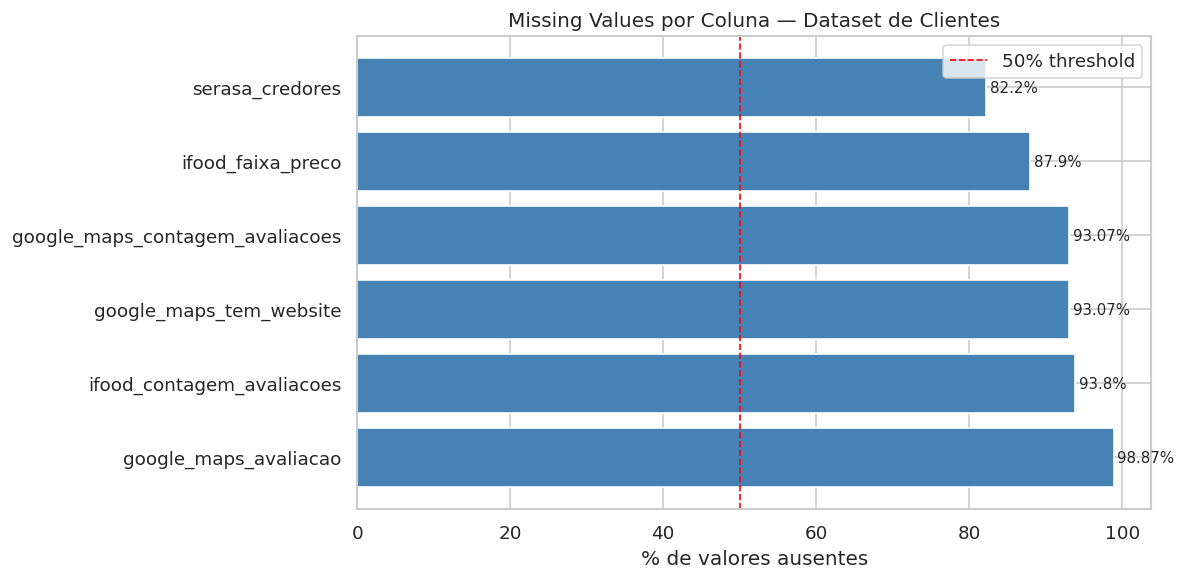

In [4]:
# Visualização dos missing values
fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(resumo.index, resumo["missing_%"], color="steelblue")
ax.axvline(x=50, color="red", linestyle="--", linewidth=1, label="50% threshold")
ax.set_xlabel("% de valores ausentes")
ax.set_title("Missing Values por Coluna — Dataset de Clientes")
ax.legend()

for i, (idx, row) in enumerate(resumo.iterrows()):
    ax.text(row["missing_%"] + 0.5, i, f'{row["missing_%"]}%', va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/01_missing_values.png",
            bbox_inches="tight")
plt.show()

### 2.3 — Classificação das Variáveis

Antes de analisar distribuições, é importante classificar cada variável pelo seu
tipo semântico — isso guia as decisões de pré-processamento e visualização.

| Variável | Tipo Semântico | Observação |
|---|---|---|
| `id_cliente` | Identificador | Não entra no modelo |
| `uf` | Categórica nominal | Poucos níveis (PE, CE, PB) |
| `municipio` | Categórica nominal | Alta cardinalidade — risco de overfitting |
| `segmento_cliente` | Categórica nominal | Anonimizado (Segmento 1-21) |
| `natureza_juridica` | Categórica nominal | Código + descrição |
| `fonte_cliente` | Categórica nominal | Anonimizado (Fonte 1-5) |
| `cnae_codigo` | Categórica hierárquica | Anonimizado, hierarquia preservada |
| `capital_social` | Numérica (intervalo) | String no formato `(150-250]` |
| `idade_cnpj` | Numérica (intervalo) | String no formato `(150-250]` |
| `serasa_contagem_negativacoes` | Numérica discreta | Pode ter zeros estruturais |
| `serasa_contagem_protestos` | Numérica discreta | Pode ter zeros estruturais |
| `serasa_credores` | Lista em string | Requer parsing — ex: `"Alimentos, Distribuição"` |
| `serasa_socio_tem_negativacao` | Booleana (0/1) | Float por causa de NaN |
| `ifood_contagem_avaliacoes` | Numérica discreta | Nulo = não está no iFood |
| `ifood_faixa_preco` | Categórica ordinal | `$`, `$$`, `$$$` — nulo = não está no iFood |
| `google_maps_avaliacao` | Numérica contínua (0-5) | Nulo = não está no Google Maps |
| `google_maps_contagem_avaliacoes` | Numérica discreta | Nulo = não está no Google Maps |
| `google_maps_tem_website` | Booleana (0/1) | Nulo = não está no Google Maps |
| `inadimplente` | **Target** (0/1) | Float por causa de possível NaN |

In [5]:
# Verificar se o target tem missing — crítico
missing_target = df["inadimplente"].isnull().sum()
print(f"Missing values no target (inadimplente): {missing_target}")

if missing_target > 0:
    print("⚠️  Atenção: existem registros sem label. Esses registros devem ser removidos antes da modelagem.")
else:
    print("✓ Target sem missing values.")

Missing values no target (inadimplente): 0
✓ Target sem missing values.


## Seção 3 — Análise da Variável Target

O primeiro passo em qualquer problema de classificação é entender a distribuição
da variável-alvo. Problemas de crédito são tipicamente **desbalanceados**: a maioria
dos clientes paga, e os inadimplentes são minoria — o que tem implicações diretas
na modelagem e na escolha de métricas.

In [6]:
# Distribuição absoluta e percentual do target
target_counts = df["inadimplente"].value_counts()
target_pct = df["inadimplente"].value_counts(normalize=True) * 100

target_resumo = pd.DataFrame({
    "contagem": target_counts,
    "percentual (%)": target_pct.round(2)
}).rename(index={0.0: "Adimplente (0)", 1.0: "Inadimplente (1)"})

display(target_resumo)
print(f"\nTaxa de inadimplência: {target_pct[1.0]:.2f}%")
print(f"Razão de desbalanceamento: 1 inadimplente para cada {target_counts[0.0]/target_counts[1.0]:.1f} adimplentes")

,contagem,percentual (%)
inadimplente,,
Adimplente (0),2060,68.6700
Inadimplente (1),940,31.3300



Taxa de inadimplência: 31.33%
Razão de desbalanceamento: 1 inadimplente para cada 2.2 adimplentes


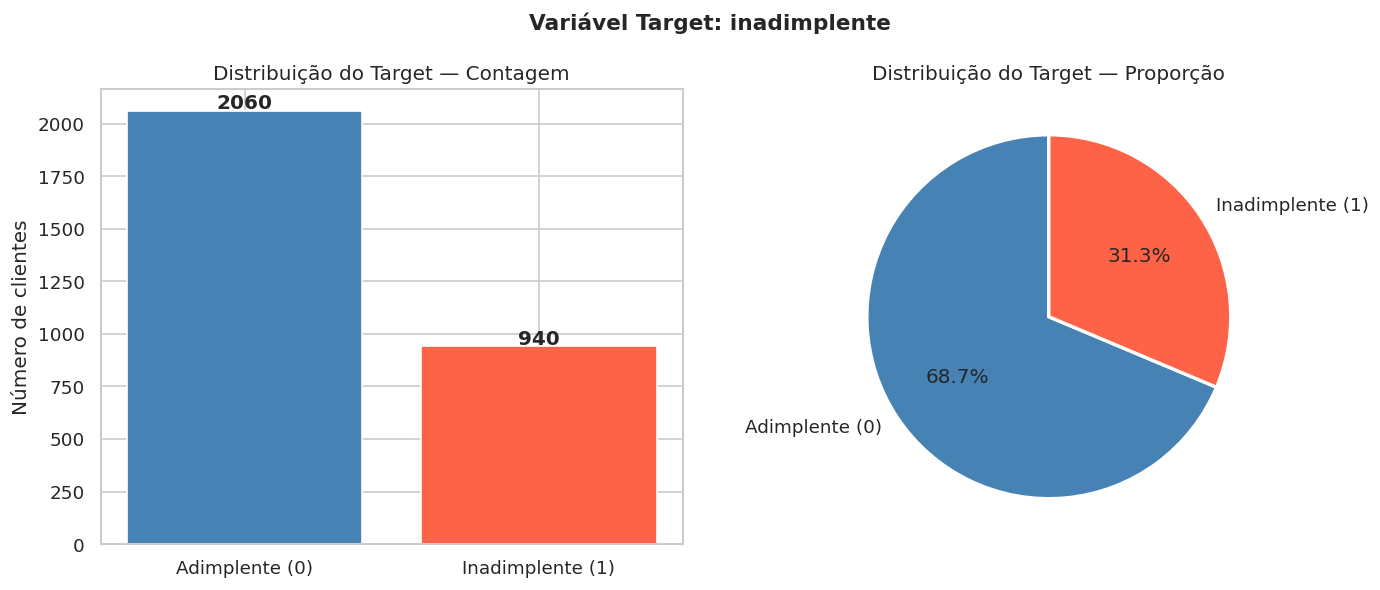

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Countplot
cores = ["steelblue", "tomato"]
axes[0].bar(["Adimplente (0)", "Inadimplente (1)"], target_counts.values, color=cores)
axes[0].set_title("Distribuição do Target — Contagem")
axes[0].set_ylabel("Número de clientes")
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Pizza
axes[1].pie(
    target_counts.values,
    labels=["Adimplente (0)", "Inadimplente (1)"],
    autopct="%1.1f%%",
    colors=cores,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Distribuição do Target — Proporção")

plt.suptitle("Variável Target: inadimplente", fontsize=13, fontweight="bold")
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/02_target.png",
            bbox_inches="tight")
plt.tight_layout()
plt.show()

### Interpretação

O dataset apresenta uma taxa de inadimplência de **31,3%** (940 clientes), contra
**68,7%** de adimplentes (2.060 clientes) — uma razão de aproximadamente 1:2,2.

Esse nível de inadimplência é elevado em comparação ao crédito tradicional, o que
reflete o perfil de risco do público atendido pela Praso: pequenos varejistas,
muitas vezes sem histórico de crédito formal, operando em segmentos de alta
rotatividade.

**Implicações para a modelagem:**
- A acurácia (accuracy) é uma métrica **enganosa** neste contexto: um modelo que
  classifica todos como adimplentes atingiria 68,7% de acurácia, mas seria inútil.
- O **ROC-AUC** é adequado pois avalia a capacidade de ordenação independentemente
  do threshold de classificação.
- Complementarmente, avaliaremos **Precision-Recall AUC**, mais sensível ao
  desempenho na classe minoritária.
- O desbalanceamento moderado (1:2,2) sugere que técnicas agressivas como SMOTE
  provavelmente não serão necessárias — o uso de `class_weight="balanced"` nos
  modelos deve ser suficiente.
- Qualquer técnica de balanceamento será aplicada **somente no conjunto de treino**,
  após a separação treino/teste, para evitar data leakage.

## Seção 4 — Análise Univariada

A análise univariada examina cada variável isoladamente, buscando compreender
sua distribuição, identificar outliers e anomalias, e levantar hipóteses sobre
seu potencial preditivo.

As variáveis serão analisadas em grupos por afinidade semântica:
1. Variáveis de intervalo (`capital_social`, `idade_cnpj`)
2. Variáveis Serasa
3. Variáveis categóricas de cadastro
4. Variáveis de presença digital (iFood e Google Maps)

### 4.1 — Variáveis de Intervalo

`capital_social` e `idade_cnpj` foram codificadas como intervalos no formato
`(150, 250]` para proteção dos dados dos clientes. Antes de qualquer análise,
precisamos converter para um valor numérico contínuo usando o **ponto médio
de cada intervalo**.

In [8]:
def intervalo_para_ponto_medio(serie):
    """
    Converte uma coluna de intervalos no formato '(150-250]' ou '[0-100]'
    para o ponto médio numérico do intervalo.
    Mantém NaN onde o valor original é nulo.
    """
    def extrair_medio(valor):
        if pd.isnull(valor):
            return np.nan
        # Remove parênteses e colchetes e divide pelo separador ','
        # Cuidado: alguns valores podem ser negativos ou ter formato especial
        valor_limpo = str(valor).strip().replace("(", "").replace("]", "").replace("[", "").replace(")", "")
        partes = valor_limpo.split(",")
        try:
            inicio = float(partes[0])
            fim = float(partes[1])
            return (inicio + fim) / 2
        except:
            return np.nan

    return serie.apply(extrair_medio)

# Aplicar nas duas colunas — criamos versões numéricas sem alterar o original
df["capital_social_num"] = intervalo_para_ponto_medio(df["capital_social"])
df["idade_cnpj_num"] = intervalo_para_ponto_medio(df["idade_cnpj"])

# Checar resultado
print("capital_social — antes vs depois:")
display(pd.DataFrame({
    "original": df["capital_social"].head(8),
    "convertido": df["capital_social_num"].head(8)
}))

print("\nidade_cnpj — antes vs depois:")
display(pd.DataFrame({
    "original": df["idade_cnpj"].head(8),
    "convertido": df["idade_cnpj_num"].head(8)
}))

capital_social — antes vs depois:


,original,convertido
0,"(1500, 2000]",1750.0000
1,"(8000, 10000]",9000.0000
2,"(1500, 2000]",1750.0000
3,"(2000, 3000]",2500.0000
4,"(8000, 10000]",9000.0000
5,"(100000, 200000]",150000.0000
6,"(1500, 2000]",1750.0000
7,"(3000, 5000]",4000.0000



idade_cnpj — antes vs depois:


,original,convertido
0,"(3000, 4000]",3500.0000
1,"(25, 50]",37.5000
2,"(3000, 4000]",3500.0000
3,"(900, 1150]",1025.0000
4,"(600, 750]",675.0000
5,"(2000, 2400]",2200.0000
6,"(900, 1150]",1025.0000
7,"(450, 600]",525.0000


In [9]:
# Estatísticas descritivas das variáveis convertidas
print("── capital_social_num ──")
display(df["capital_social_num"].describe().to_frame().T)

print("\n── idade_cnpj_num ──")
display(df["idade_cnpj_num"].describe().to_frame().T)

# Checar se sobraram nulos após conversão
print(f"\nNulos em capital_social após conversão: {df['capital_social_num'].isnull().sum()}")
print(f"Nulos em idade_cnpj após conversão:    {df['idade_cnpj_num'].isnull().sum()}")

── capital_social_num ──


,count,mean,std,min,25%,50%,75%,max
capital_social_num,3000.0000,66730342.1552,1825008899.2683,0.5000,4000.0000,9000.0000,17500.0000,50005000000.0000



── idade_cnpj_num ──


,count,mean,std,min,25%,50%,75%,max
idade_cnpj_num,3000.0000,2768.3333,3927.4891,12.5000,400.0000,1225.0000,3500.0000,16500.0000



Nulos em capital_social após conversão: 0
Nulos em idade_cnpj após conversão:    0


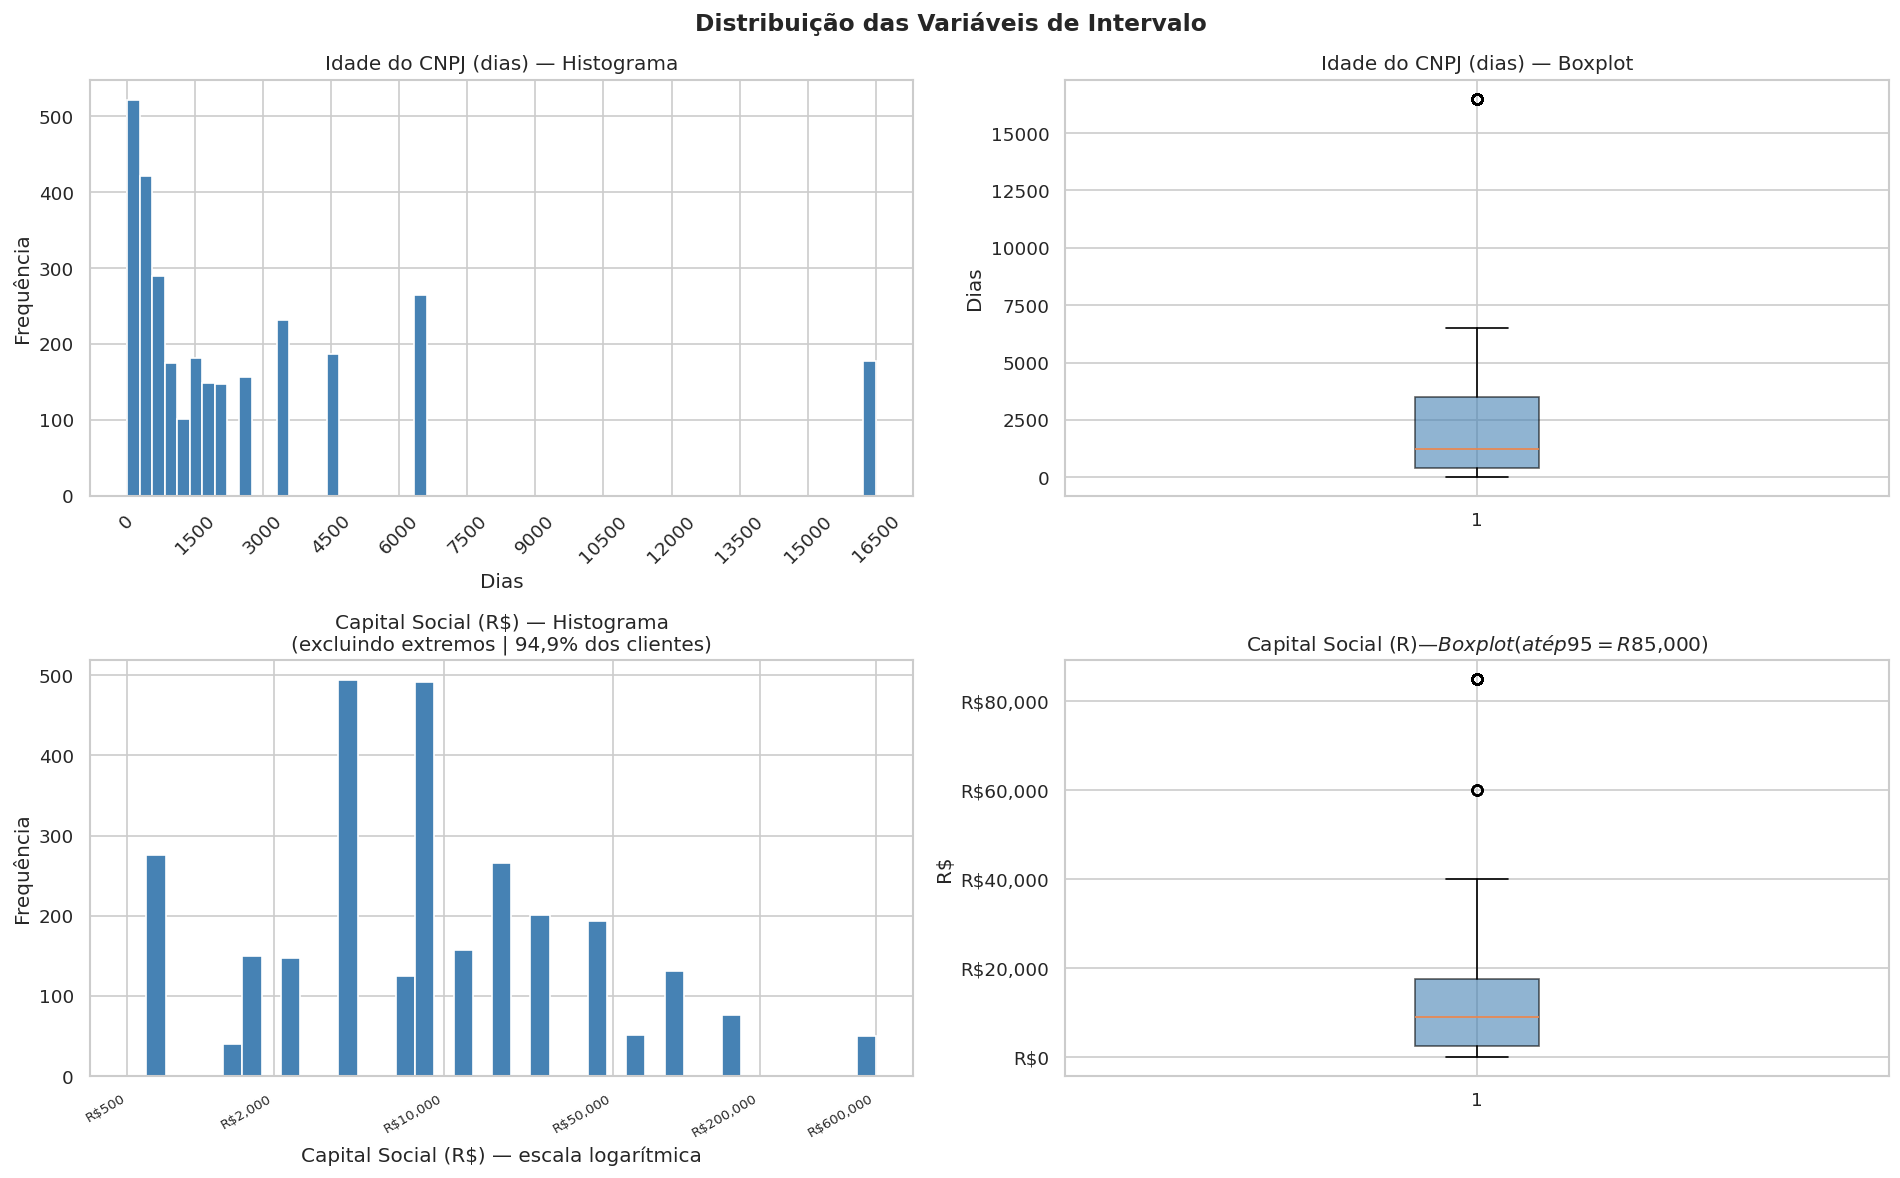

  Abaixo de R$ 500:    131 clientes (4.4%)
  Acima de R$ 600k:    20 clientes (0.7%)
  Total excluído:      5.1%


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# IDADE DO CNPJ

# Histograma
axes[0, 0].hist(df["idade_cnpj_num"].dropna(), bins=60, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Idade do CNPJ (dias) — Histograma")
axes[0, 0].set_xlabel("Dias")
axes[0, 0].set_ylabel("Frequência")
axes[0, 0].set_xticks(range(0, int(df["idade_cnpj_num"].max()) + 1500, 1500))
axes[0, 0].tick_params(axis="x", rotation=45)

# Boxplot
axes[0, 1].boxplot(df["idade_cnpj_num"].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[0, 1].set_title("Idade do CNPJ (dias) — Boxplot")
axes[0, 1].set_ylabel("Dias")

# CAPITAL SOCIAL

dados_capital = df["capital_social_num"].dropna()
dados_foco = dados_capital[(dados_capital >= 500) & (dados_capital <= 600000)]

# Histograma com escala log
bins_log = np.logspace(np.log10(500), np.log10(600000), 40)

axes[1, 0].hist(dados_foco, bins=bins_log, color="steelblue", edgecolor="white")
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("Capital Social (R$) — Histograma\n(excluindo extremos | 94,9% dos clientes)")
axes[1, 0].set_xlabel("Capital Social (R$) — escala logarítmica")
axes[1, 0].set_ylabel("Frequência")

ticks_capital = [500, 2000, 10000, 50000, 200000, 600000]
axes[1, 0].set_xticks(ticks_capital)
axes[1, 0].set_xticklabels(
    [f"R${x:,.0f}" for x in ticks_capital],
    rotation=30, ha="right", fontsize=8
)

# Boxplot até p95
p95 = dados_capital.quantile(0.95)
dados_clip = dados_capital[dados_capital <= p95]

axes[1, 1].boxplot(dados_clip, vert=True, patch_artist=True,
                   boxprops=dict(facecolor="steelblue", alpha=0.6))
axes[1, 1].set_title(f"Capital Social (R$) — Boxplot (até p95 = R${p95:,.0f})")
axes[1, 1].set_ylabel("R$")
axes[1, 1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"R${x:,.0f}")
)

plt.suptitle("Distribuição das Variáveis de Intervalo", fontsize=14, fontweight="bold")
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/03_variaveis_intervalo.png",
            bbox_inches="tight")
plt.tight_layout()
plt.show()

# Resumo dos extremos print("Capital Social — Extremos )
print(f"  Abaixo de R$ 500:    {(dados_capital < 500).sum()} clientes ({(dados_capital < 500).mean()*100:.1f}%)")
print(f"  Acima de R$ 600k:    {(dados_capital > 600000).sum()} clientes ({(dados_capital > 600000).mean()*100:.1f}%)")
print(f"  Total excluído:      5.1%")

### Interpretação — Variáveis de Intervalo

**Idade do CNPJ (dias desde abertura até cadastro na Praso):**

- Distribuição fortemente assimétrica à direita (right-skewed), com frequência
  decrescente à medida que a idade aumenta — quanto mais novo o CNPJ, maior a
  concentração de clientes.
- Mediana de 1.225 dias (~3,4 anos), confirmando que a base da Praso é composta
  majoritariamente por empresas jovens.
- A partir de ~6.000 dias (16 anos) não há registros até o outlier isolado em
  ~16.500 dias (45 anos), indicando um vazio completo nessa faixa e um CNPJ
  atípico no extremo.
- A assimetria sugere que uma transformação logarítmica pode ser útil na
  modelagem para suavizar a cauda.

**Capital Social (R$):**

- Distribuição extremamente assimétrica, com a massa principal (caixa do boxplot)
  concentrada entre 0 e  20.000 — perfil típico de microempreendedores e
  pequenos varejistas.
- Mediana de 9.000 contra média de 66 milhões — a média é completamente
  distorcida por poucos outliers (máximo de 50 bilhões).
- Para a visualização no histograma, foram excluídos 5,1% dos dados: 131
  clientes abaixo de 500 (incluindo 98 com capital social de 0,50,
  possivelmente MEIs com capital simbólico) e 20 clientes acima de 600 mil.
  Essa exclusão é apenas visual — os registros permanecem no dataset e o
  tratamento de outliers será definido no pré-processamento.
- Para modelagem, transformação logarítmica é praticamente obrigatória nesta
  variável dada a amplitude extrema dos valores (0,50 a 50 bilhões).

### 4.2 — Variáveis Serasa

As variáveis Serasa representam o histórico de crédito formal do estabelecimento
e de seus sócios. São informações extraídas de bureaus de crédito no momento do
cadastro e tendem a ser das features mais preditivas em modelos de crédito —
clientes com histórico de inadimplência formal têm naturalmente maior risco.

As quatro variáveis analisadas são:
- `serasa_contagem_negativacoes`: número total de negativações registradas
- `serasa_contagem_protestos`: número total de protestos em cartório
- `serasa_socio_tem_negativacao`: se algum sócio possui negativação (0/1)
- `serasa_credores`: lista de segmentos de empresas para quem o cliente deve

In [11]:
# Estatísticas descritivas das variáveis numéricas Serasa
serasa_num = ["serasa_contagem_negativacoes", "serasa_contagem_protestos"]

print(" Estatísticas Descritivas")
display(df[serasa_num].describe().T)

print("\n Contagem de zeros (clientes sem ocorrência)")
for col in serasa_num:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f"  {col}: {zeros} clientes sem ocorrência ({pct:.1f}%)")

print("\n Valores únicos")
for col in serasa_num:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

 Estatísticas Descritivas


,count,mean,std,min,25%,50%,75%,max
serasa_contagem_negativacoes,3000.0000,1.0030,4.4646,0.0000,0.0000,0.0000,0.0000,141.0000
serasa_contagem_protestos,3000.0000,0.2633,1.9363,0.0000,0.0000,0.0000,0.0000,79.0000



 Contagem de zeros (clientes sem ocorrência)
  serasa_contagem_negativacoes: 2369 clientes sem ocorrência (79.0%)
  serasa_contagem_protestos: 2769 clientes sem ocorrência (92.3%)

 Valores únicos
  serasa_contagem_negativacoes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0), np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(17.0), np.float64(18.0), np.float64(19.0), np.float64(20.0), np.float64(21.0), np.float64(22.0), np.float64(24.0), np.float64(26.0), np.float64(28.0), np.float64(29.0), np.float64(30.0), np.float64(34.0), np.float64(37.0), np.float64(40.0), np.float64(41.0), np.float64(52.0), np.float64(56.0), np.float64(64.0), np.float64(141.0)]
  serasa_contagem_protestos: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)

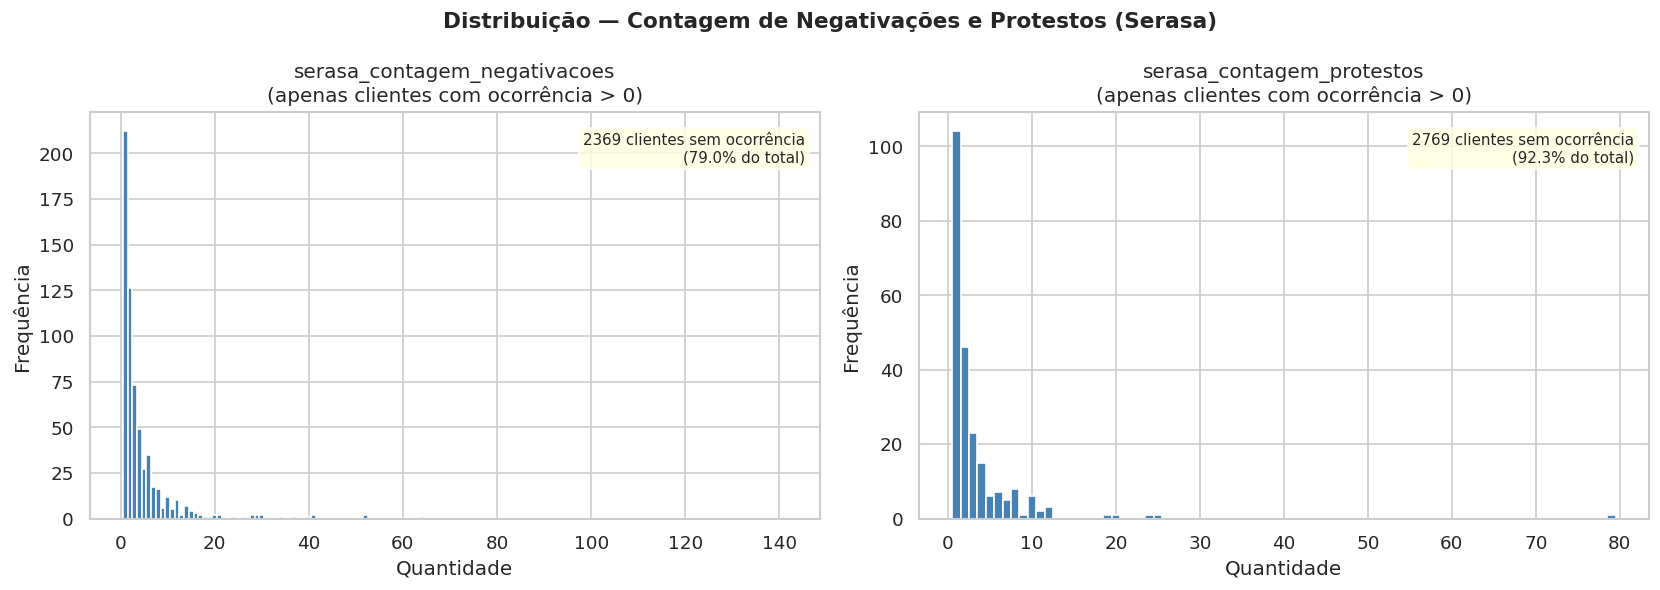

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(serasa_num):
    # Focar nos valores > 0 para ver a distribuição real de quem tem ocorrência
    dados = df[col].dropna()
    dados_pos = dados[dados > 0]

    axes[i].hist(dados_pos, bins=range(1, int(dados_pos.max()) + 2),
                 color="steelblue", edgecolor="white", align="left")
    axes[i].set_title(f"{col}\n(apenas clientes com ocorrência > 0)")
    axes[i].set_xlabel("Quantidade")
    axes[i].set_ylabel("Frequência")

    # Anotação dos zeros no gráfico
    zeros = (dados == 0).sum()
    pct_zeros = zeros / len(dados) * 100
    axes[i].annotate(f"{zeros} clientes sem ocorrência\n({pct_zeros:.1f}% do total)",
                     xy=(0.98, 0.95), xycoords="axes fraction",
                     ha="right", va="top", fontsize=9,
                     bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.suptitle("Distribuição — Contagem de Negativações e Protestos (Serasa)", fontsize=13, fontweight="bold")
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/04_contagem_negativacoes.png",
            bbox_inches="tight")
plt.tight_layout()
plt.show()

In [13]:
# serasa_socio_tem_negativacao — variável booleana
print("serasa_socio_tem_negativacao")
contagem = df["serasa_socio_tem_negativacao"].value_counts(dropna=False)
pct = df["serasa_socio_tem_negativacao"].value_counts(dropna=False, normalize=True) * 100

display(pd.DataFrame({
    "contagem": contagem,
    "percentual (%)": pct.round(2)
}).rename(index={0.0: "Sem negativação (0)", 1.0: "Com negativação (1)", float("nan"): "Nulo"}))

serasa_socio_tem_negativacao


,contagem,percentual (%)
serasa_socio_tem_negativacao,,
Sem negativação (0),1573,52.4300
Com negativação (1),1427,47.5700


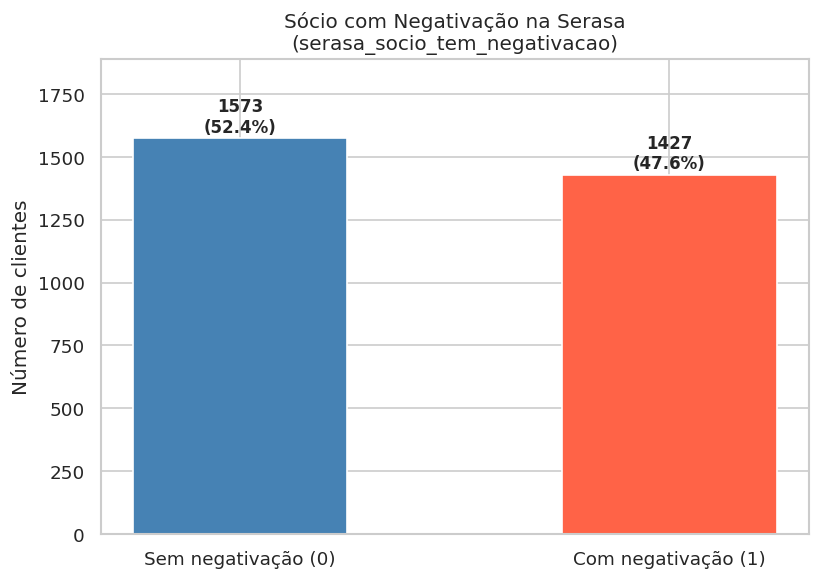

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

labels = ["Sem negativação (0)", "Com negativação (1)"]
valores = [1573, 1427]
cores = ["steelblue", "tomato"]

bars = ax.bar(labels, valores, color=cores, edgecolor="white", width=0.5)
ax.set_title("Sócio com Negativação na Serasa\n(serasa_socio_tem_negativacao)")
ax.set_ylabel("Número de clientes")

for bar, val in zip(bars, valores):
    pct = val / sum(valores) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 10,
            f"{val}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_ylim(0, max(valores) * 1.2)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/05_socio_com_negativacao.png",
            bbox_inches="tight")
plt.show()

### Interpretação — Variáveis Serasa

**Contagem de Negativações e Protestos:**
- Ambas as variáveis apresentam distribuição em cauda longa (long-tail), com
  forte concentração em zero e poucos casos de valores elevados.
- 79,0% dos clientes não possuem nenhuma negativação registrada na Serasa;
  92,3% não possuem nenhum protesto em cartório.
- Os outliers extremos (141 negativações e 79 protestos) representam clientes
  em situação financeira muito crítica — serão investigados na análise bivariada.
- Protestos são eventos mais raros e formalmente mais graves que negativações,
  o que se reflete na menor frequência observada.
- Para modelagem, ambas as variáveis precisarão de tratamento de outliers e
  possivelmente transformação logarítmica (log1p), dado que contêm zeros.

**Sócio com Negativação (serasa_socio_tem_negativacao):**
- Variável completa — sem nenhum valor nulo.
- Distribuição próxima ao equilíbrio: 52,4% dos clientes sem negativação de
  sócio e 47,6% com. Isso reforça o perfil de risco elevado da base da Praso,
  composta por pequenos empreendedores com histórico de crédito comprometido,
  público que frequentemente não teria acesso ao crédito tradicional.
- Por ser binária e completa, essa variável entra diretamente no modelo
  sem necessidade de imputação ou encoding especial.

### 4.2.1 — serasa_credores

Esta variável é uma lista em string que contém os segmentos de até 5 empresas
para as quais o cliente possui dívidas registradas na Serasa. Exemplos:
- `"Alimentos e Bebidas, Alimentos e Bebidas, Distribuição"`
- `"Banco, Telecomunicações"`
- `NaN` → cliente não deve para nenhuma empresa registrada

Antes de analisar a distribuição, precisamos fazer o parsing dos segmentos
para entender quais tipos de credores são mais comuns na base.

In [15]:
# Visão geral da coluna
print("── serasa_credores ──")
print(f"Nulos: {df['serasa_credores'].isnull().sum()} ({df['serasa_credores'].isnull().mean()*100:.1f}%)")
print(f"Preenchidos: {df['serasa_credores'].notna().sum()} ({df['serasa_credores'].notna().mean()*100:.1f}%)")

# Amostrar valores para entender o formato
print("\n── Exemplos de valores preenchidos ──")
display(df.loc[df["serasa_credores"].notna(), "serasa_credores"].sample(10, random_state=SEED).values)

── serasa_credores ──
Nulos: 2466 (82.2%)
Preenchidos: 534 (17.8%)

── Exemplos de valores preenchidos ──


array(['Tecnologia e Pagamentos', 'Financeiro', 'Bancos e Financeiro',
       'Telecomunicações', 'Distribuição',
       'Bancos e Financeiro, Contabilidade, Comércio, Telecomunicações',
       'Tecnologia e Pagamentos, Financeiro', 'Diversos',
       'Alimentos e Bebidas, Alimentos e Bebidas, Impressão e Gráficas, Distribuição',
       'Financeiro, Distribuição, Distribuição, Bancos e Financeiro'],
      dtype=object)

In [16]:
# Parsing: transformar cada linha em lista de segmentos
def parse_credores(valor):
    if pd.isnull(valor):
        return []
    return [c.strip() for c in str(valor).split(",") if c.strip()]

df["credores_lista"] = df["serasa_credores"].apply(parse_credores)
df["qtd_credores"] = df["credores_lista"].apply(len)

# Distribuição da quantidade de credores por cliente
print("── Quantidade de credores por cliente ──")
display(df["qtd_credores"].value_counts().sort_index().to_frame("contagem").assign(
    percentual=lambda x: (x["contagem"] / len(df) * 100).round(2)
))

── Quantidade de credores por cliente ──


,contagem,percentual
qtd_credores,,
0,2466,82.2000
1,324,10.8000
2,99,3.3000
3,70,2.3300
4,29,0.9700
5,7,0.2300
6,3,0.1000
7,2,0.0700


In [17]:
# Extrair todos os segmentos de credores e contar frequência global
from collections import Counter

todos_segmentos = [seg for lista in df["credores_lista"] for seg in lista]
freq_segmentos = Counter(todos_segmentos)

df_segmentos = (pd.DataFrame(freq_segmentos.items(), columns=["segmento", "ocorrencias"])
                .sort_values("ocorrencias", ascending=False)
                .reset_index(drop=True))

print(f"Total de segmentos únicos: {df_segmentos.shape[0]}")
print(f"Total de ocorrências: {len(todos_segmentos)}\n")
display(df_segmentos)

Total de segmentos únicos: 30
Total de ocorrências: 915



,segmento,ocorrencias
0,Alimentos e Bebidas,210
1,Bancos e Financeiro,198
2,Tecnologia e Pagamentos,89
3,Distribuição,88
4,Financeiro,84
5,Saúde,58
6,Telecomunicações,44
7,Diversos,28
8,Comércio,25
9,Tecnologia,13


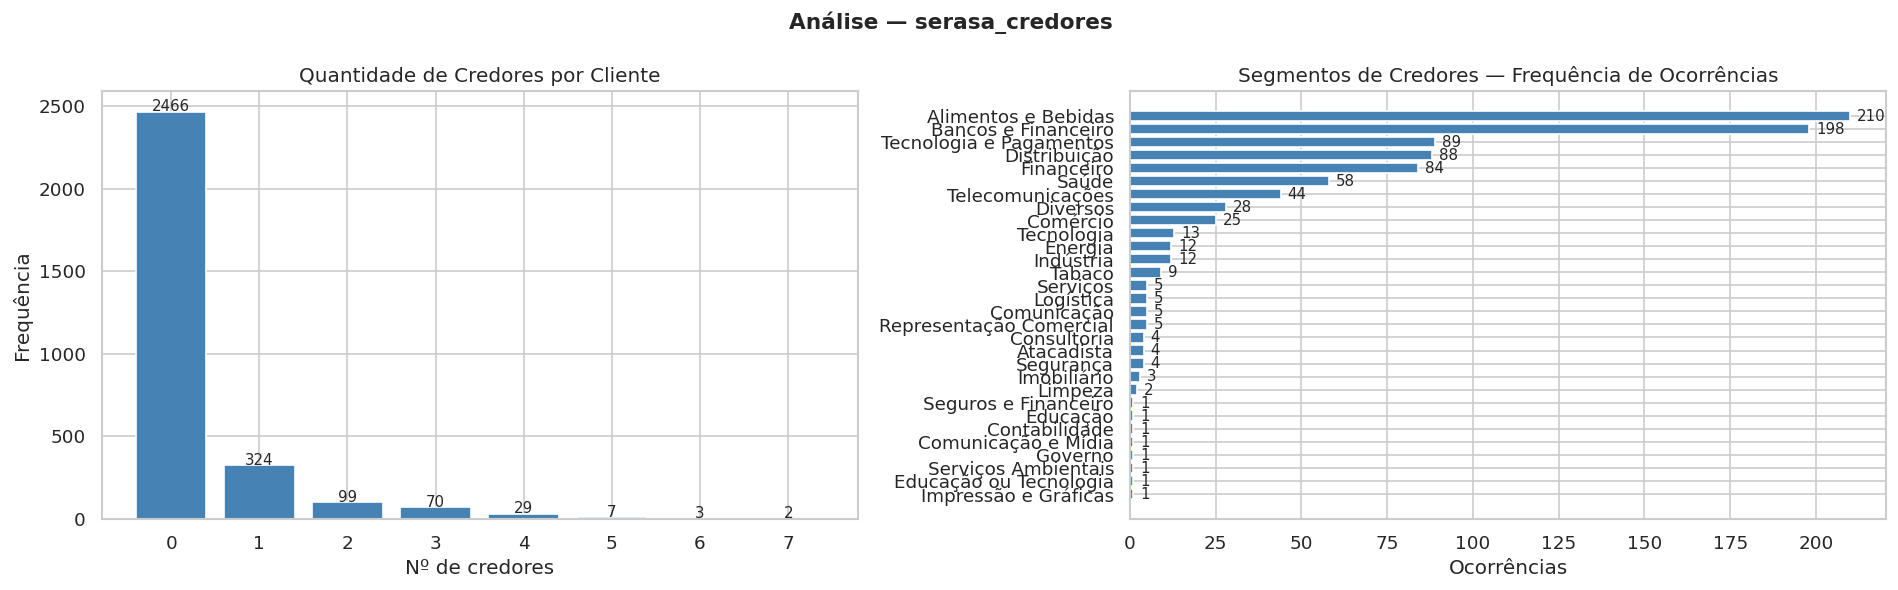

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Quantidade de credores por cliente ────────────────────────────────────────
contagem_credores = df["qtd_credores"].value_counts().sort_index()

axes[0].bar(contagem_credores.index, contagem_credores.values,
            color="steelblue", edgecolor="white")
axes[0].set_title("Quantidade de Credores por Cliente")
axes[0].set_xlabel("Nº de credores")
axes[0].set_ylabel("Frequência")
axes[0].set_xticks(contagem_credores.index)

for x, y in zip(contagem_credores.index, contagem_credores.values):
    axes[0].text(x, y + 5, str(y), ha="center", fontsize=9)

# ── Frequência dos segmentos de credores ──────────────────────────────────────
axes[1].barh(df_segmentos["segmento"], df_segmentos["ocorrencias"],
             color="steelblue", edgecolor="white")
axes[1].set_title("Segmentos de Credores — Frequência de Ocorrências")
axes[1].set_xlabel("Ocorrências")
axes[1].invert_yaxis()

for i, (seg, val) in enumerate(zip(df_segmentos["segmento"], df_segmentos["ocorrencias"])):
    axes[1].text(val + 2, i, str(val), va="center", fontsize=9)

plt.suptitle("Análise — serasa_credores", fontsize=13, fontweight="bold")
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/06_serasa_credores.png",
            bbox_inches="tight")
plt.tight_layout()
plt.show()

In [19]:
# Remover colunas temporárias de parsing — serão recriadas no preprocessing
df.drop(columns=["credores_lista", "qtd_credores"], inplace=True)

### Interpretação — serasa_credores

**Estrutura da variável:**
- 82,2% dos clientes não possuem nenhum credor registrado na Serasa (valor nulo),
  o que significa ausência de dívida formal — informação com significado semântico
  relevante, não dado faltante.
- Dos 534 clientes com credores, a maioria (324, ou 60,7%) deve para apenas uma
  empresa. Apenas 3,6% da base total devem para 3 ou mais credores.
- 5 clientes apresentam mais de 5 credores (limite descrito na documentação),
  possivelmente por inconsistência pontual nos dados — representam 0,17% da base
  e não demandam tratamento especial.

**Segmentos de credores:**
- "Alimentos e Bebidas" (210 ocorrências) e "Bancos e Financeiro" (198) dominam,
  representando juntos cerca de 40% de todas as ocorrências. Isso é coerente com
  o perfil da base: varejistas do setor alimentício com dívidas junto a seus
  próprios fornecedores e instituições financeiras.
- Dos 30 segmentos únicos identificados, 15 possuem 5 ou menos ocorrências.
  Para a modelagem, esses segmentos raros provavelmente serão agrupados em uma
  categoria "Outros" para evitar overfitting.

**Decisões para o pré-processamento:**
- Criar variável `qtd_credores` (0 a 5+) como feature numérica.
- Aplicar MultiLabelBinarizer nos segmentos de credores para gerar features
  binárias (tem/não tem dívida com cada segmento).
- Agrupar segmentos com baixa frequência em "Outros" antes do encoding.
- A flag de presença (tem_credores = 0/1) pode já capturar boa parte do sinal
  preditivo, dado que 82,2% da base é nula.

### 4.3 — Variáveis Categóricas de Cadastro

Estas variáveis descrevem características do estabelecimento obtidas no momento
do cadastro: localização geográfica, tipo de negócio, forma jurídica e canal de
aquisição. Todas são categóricas nominais e precisamos entender a cardinalidade,
a distribuição e a representatividade de cada categoria antes de decidir como
codificá-las para o modelo.

In [20]:
cat_cadastro = ["uf", "segmento_cliente", "natureza_juridica", "fonte_cliente", "municipio"]

print("── Resumo das Variáveis Categóricas de Cadastro ──\n")
for col in cat_cadastro:
    n_unicos = df[col].nunique()
    nulos = df[col].isnull().sum()
    top = df[col].value_counts().head(1)
    print(f"{col}")
    print(f"  Categorias únicas: {n_unicos}")
    print(f"  Nulos: {nulos}")
    print(f"  Categoria mais frequente: '{top.index[0]}' ({top.values[0]} | {top.values[0]/len(df)*100:.1f}%)")
    print()

── Resumo das Variáveis Categóricas de Cadastro ──

uf
  Categorias únicas: 1
  Nulos: 0
  Categoria mais frequente: 'CE' (3000 | 100.0%)

segmento_cliente
  Categorias únicas: 21
  Nulos: 0
  Categoria mais frequente: 'Segmento 16' (613 | 20.4%)

natureza_juridica
  Categorias únicas: 5
  Nulos: 0
  Categoria mais frequente: '213-5 - Empresário (Individual)' (2249 | 75.0%)

fonte_cliente
  Categorias únicas: 5
  Nulos: 0
  Categoria mais frequente: 'Fonte 1' (2055 | 68.5%)

municipio
  Categorias únicas: 36
  Nulos: 0
  Categoria mais frequente: 'FORTALEZA' (1934 | 64.5%)



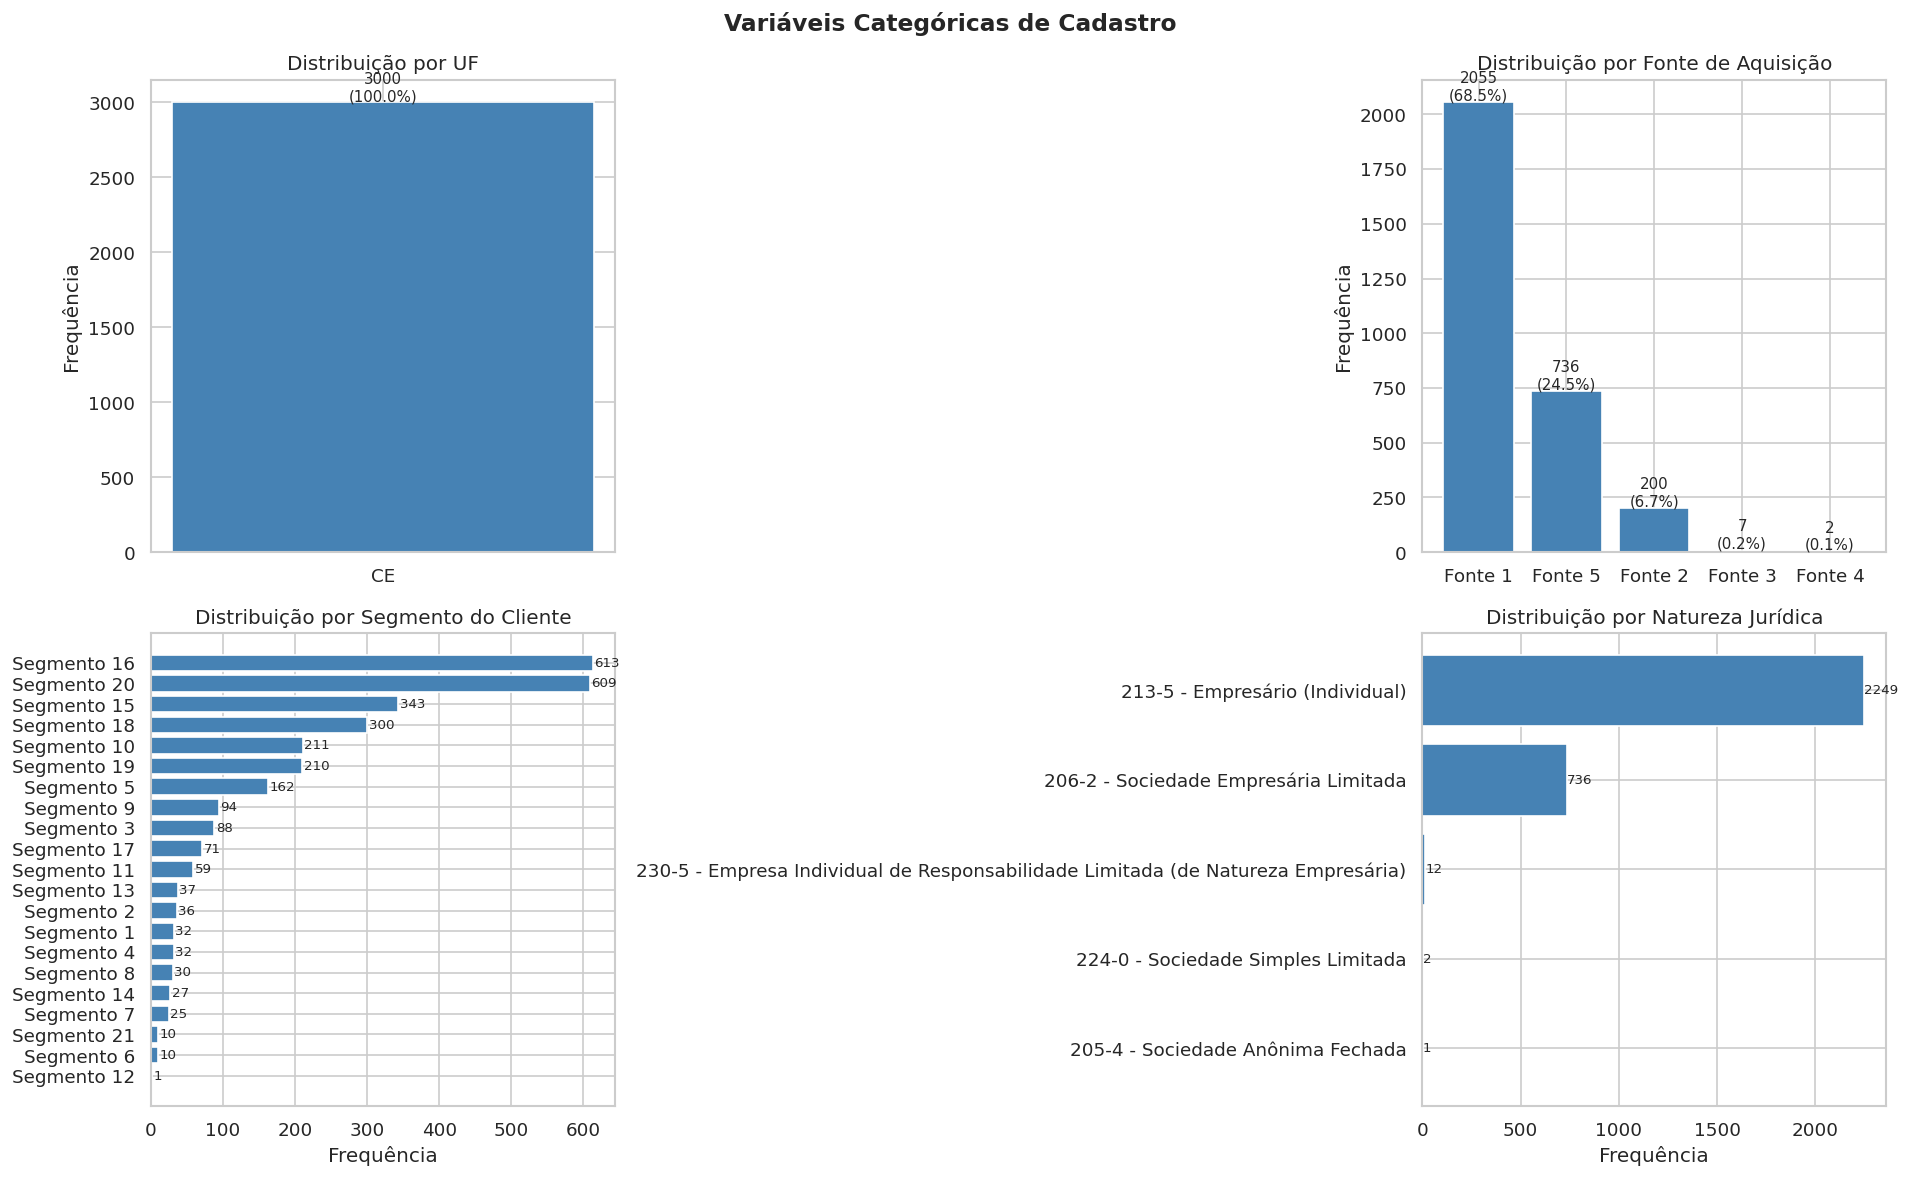

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── UF ────────────────────────────────────────────────────────────────────────
contagem_uf = df["uf"].value_counts()
axes[0, 0].bar(contagem_uf.index, contagem_uf.values, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Distribuição por UF")
axes[0, 0].set_ylabel("Frequência")
for i, (cat, val) in enumerate(zip(contagem_uf.index, contagem_uf.values)):
    axes[0, 0].text(i, val + 10, f"{val}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9)

# ── Fonte Cliente ─────────────────────────────────────────────────────────────
contagem_fonte = df["fonte_cliente"].value_counts()
axes[0, 1].bar(contagem_fonte.index, contagem_fonte.values, color="steelblue", edgecolor="white")
axes[0, 1].set_title("Distribuição por Fonte de Aquisição")
axes[0, 1].set_ylabel("Frequência")
for i, (cat, val) in enumerate(zip(contagem_fonte.index, contagem_fonte.values)):
    axes[0, 1].text(i, val + 10, f"{val}\n({val/len(df)*100:.1f}%)", ha="center", fontsize=9)

# ── Segmento Cliente ──────────────────────────────────────────────────────────
contagem_seg = df["segmento_cliente"].value_counts()
axes[1, 0].barh(contagem_seg.index, contagem_seg.values, color="steelblue", edgecolor="white")
axes[1, 0].set_title("Distribuição por Segmento do Cliente")
axes[1, 0].set_xlabel("Frequência")
axes[1, 0].invert_yaxis()
for i, val in enumerate(contagem_seg.values):
    axes[1, 0].text(val + 2, i, str(val), va="center", fontsize=8)

# ── Natureza Jurídica ─────────────────────────────────────────────────────────
contagem_nat = df["natureza_juridica"].value_counts()
axes[1, 1].barh(contagem_nat.index, contagem_nat.values, color="steelblue", edgecolor="white")
axes[1, 1].set_title("Distribuição por Natureza Jurídica")
axes[1, 1].set_xlabel("Frequência")
axes[1, 1].invert_yaxis()
for i, val in enumerate(contagem_nat.values):
    axes[1, 1].text(val + 2, i, str(val), va="center", fontsize=8)

plt.suptitle("Variáveis Categóricas de Cadastro", fontsize=14, fontweight="bold")
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/07_categoricas_cadastro.png",
            bbox_inches="tight")
plt.tight_layout()
plt.show()

In [22]:
# Município — análise separada por conta da alta cardinalidade
print("── Município ──")
print(f"Total de municípios únicos: {df['municipio'].nunique()}\n")

contagem_mun = df["municipio"].value_counts()
print("Top 15 municípios:")
display(contagem_mun.head(15).to_frame("contagem").assign(
    percentual=lambda x: (x["contagem"] / len(df) * 100).round(2)
))

print(f"\nMunicípios com menos de 10 clientes: {(contagem_mun < 10).sum()} de {len(contagem_mun)}")
print(f"Clientes nesses municípios: {contagem_mun[contagem_mun < 10].sum()} ({contagem_mun[contagem_mun < 10].sum()/len(df)*100:.1f}%)")

── Município ──
Total de municípios únicos: 36

Top 15 municípios:


,contagem,percentual
municipio,,
FORTALEZA,1934,64.4700
CAUCAIA,347,11.5700
MARACANAU,109,3.6300
AQUIRAZ,85,2.8300
EUSEBIO,64,2.1300
ARACATI,63,2.1000
HORIZONTE,47,1.5700
CASCAVEL,42,1.4000
ITAITINGA,41,1.3700



Municípios com menos de 10 clientes: 17 de 36
Clientes nesses municípios: 41 (1.4%)


### Interpretação — Variáveis Categóricas de Cadastro

**UF (Unidade da Federação):**
- 100% dos registros são do Ceará (CE). A variável tem variância zero e será
  excluída do modelo — não há informação discriminativa.
- Isso indica que o dataset disponibilizado corresponde a uma partição geográfica
  dos dados da Praso, restrita ao estado do Ceará.

**Fonte de Aquisição do Cliente (fonte_cliente):**
- Forte concentração: Fonte 1 (68,5%) e Fonte 5 (24,5%) representam juntas 93%
  da base.
- Fonte 3 (7 clientes) e Fonte 4 (2 clientes) possuem representatividade
  insuficiente para análise individual e deverão ser agrupadas no preprocessing.

**Segmento do Cliente (segmento_cliente):**
- 21 segmentos anonimizados. Segmentos 16 e 20 lideram com ~20% cada.
- Distribuição mais equilibrada que as demais categóricas, mas ainda com cauda
  longa: Segmento 12 possui apenas 1 registro.
- Segmentos com baixa representatividade podem causar overfitting — agrupar os
  menos frequentes será avaliado no preprocessing.

**Natureza Jurídica (natureza_juridica):**
- Forte concentração em "213-5 - Empresário (Individual)" (75,0%), seguido de
  "206-2 - Sociedade Empresária Limitada" (24,5%).
- As 3 categorias restantes somam apenas 15 registros (0,5%) — serão agrupadas
  em "Outros".

**Município:**
- 36 municípios únicos, com Fortaleza dominando (64,5%), seguido por Caucaia
  (11,6%) e os demais municípios da região metropolitana.
- 17 municípios com menos de 10 clientes, totalizando apenas 1,4% da base.
- Alta cardinalidade com baixa representatividade nos municípios menores
  representa risco de overfitting. Para a modelagem, considerar agrupamentos
  como "Fortaleza", "Região Metropolitana" e "Interior".

### 4.4 — Variáveis de Presença Digital (iFood e Google Maps)

Estas variáveis indicam a presença e o desempenho dos estabelecimentos em
plataformas digitais. Conforme identificado na Seção 2, possuem os maiores
percentuais de missing values do dataset (87-98%), e os nulos têm significado
semântico: o estabelecimento simplesmente não está cadastrado na plataforma.

**iFood:**
- `ifood_contagem_avaliacoes`: número total de avaliações (object — investigar)
- `ifood_faixa_preco`: faixa de preço ($, $$, $$$)

**Google Maps:**
- `google_maps_avaliacao`: nota de 0 a 5 (object — investigar)
- `google_maps_contagem_avaliacoes`: número total de avaliações (object — investigar)
- `google_maps_tem_website`: se possui site vinculado (0/1)

In [23]:
# Primeiro: entender por que colunas numéricas estão como object
cols_digitais = ["ifood_contagem_avaliacoes", "ifood_faixa_preco",
                 "google_maps_avaliacao", "google_maps_contagem_avaliacoes",
                 "google_maps_tem_website"]

print("── Tipos e valores únicos ──\n")
for col in cols_digitais:
    n_preenchidos = df[col].notna().sum()
    pct_preenchidos = n_preenchidos / len(df) * 100
    print(f"{col}  (dtype: {df[col].dtype})")
    print(f"  Preenchidos: {n_preenchidos} ({pct_preenchidos:.1f}%)")
    print(f"  Valores únicos: {df[col].dropna().nunique()}")
    print(f"  Amostra: {df[col].dropna().unique()[:10]}")
    print()

── Tipos e valores únicos ──

ifood_contagem_avaliacoes  (dtype: object)
  Preenchidos: 186 (6.2%)
  Valores únicos: 11
  Amostra: ['(50, 100]' '(0, 5]' '(5, 10]' '(10, 20]' '(200, 500]' '(20, 30]'
 '(30, 50]' '(100, 200]' '(500, 1000]' '(1500, 2000]']

ifood_faixa_preco  (dtype: object)
  Preenchidos: 363 (12.1%)
  Valores únicos: 5
  Amostra: ['$$' '$' '$$$$' '$$$' '$$$$$']

google_maps_avaliacao  (dtype: object)
  Preenchidos: 34 (1.1%)
  Valores únicos: 5
  Amostra: ['(4.5, 5.0]' '(1.0, 2.0]' '(0.0, 1.0]' '(3.0, 4.0]' '(2.0, 3.0]']

google_maps_contagem_avaliacoes  (dtype: object)
  Preenchidos: 208 (6.9%)
  Valores únicos: 14
  Amostra: ['(30, 50]' '(10, 20]' '(100, 200]' '(500, 750]' '(300, 500]'
 '(1000, 2500]' '(20, 30]' '(0, 5]' '(2500, 5000]' '(750, 1000]']

google_maps_tem_website  (dtype: float64)
  Preenchidos: 208 (6.9%)
  Valores únicos: 1
  Amostra: [1.]



In [24]:
# Converter intervalos para ponto médio — reutilizando a função da Seção 4.1
cols_intervalo_digital = ["ifood_contagem_avaliacoes", "google_maps_avaliacao",
                          "google_maps_contagem_avaliacoes"]

for col in cols_intervalo_digital:
    df[f"{col}_num"] = intervalo_para_ponto_medio(df[col])
    preenchidos = df[f"{col}_num"].notna().sum()
    print(f"{col} → convertido | Preenchidos: {preenchidos}")

display(df[["ifood_contagem_avaliacoes", "ifood_contagem_avaliacoes_num"]].dropna().head(8))
display(df[["google_maps_avaliacao", "google_maps_avaliacao_num"]].dropna().head(8))
display(df[["google_maps_contagem_avaliacoes", "google_maps_contagem_avaliacoes_num"]].dropna().head(8))

ifood_contagem_avaliacoes → convertido | Preenchidos: 186
google_maps_avaliacao → convertido | Preenchidos: 34
google_maps_contagem_avaliacoes → convertido | Preenchidos: 208


,ifood_contagem_avaliacoes,ifood_contagem_avaliacoes_num
0,"(50, 100]",75.0000
19,"(0, 5]",2.5000
21,"(5, 10]",7.5000
52,"(10, 20]",15.0000
63,"(200, 500]",350.0000
84,"(20, 30]",25.0000
134,"(0, 5]",2.5000
138,"(30, 50]",40.0000


,google_maps_avaliacao,google_maps_avaliacao_num
275,"(4.5, 5.0]",4.7500
434,"(1.0, 2.0]",1.5000
475,"(0.0, 1.0]",0.5000
502,"(3.0, 4.0]",3.5000
514,"(4.5, 5.0]",4.7500
541,"(0.0, 1.0]",0.5000
640,"(4.5, 5.0]",4.7500
660,"(0.0, 1.0]",0.5000


,google_maps_contagem_avaliacoes,google_maps_contagem_avaliacoes_num
20,"(30, 50]",40.0000
58,"(10, 20]",15.0000
73,"(10, 20]",15.0000
84,"(10, 20]",15.0000
96,"(10, 20]",15.0000
115,"(100, 200]",150.0000
134,"(500, 750]",625.0000
141,"(300, 500]",400.0000


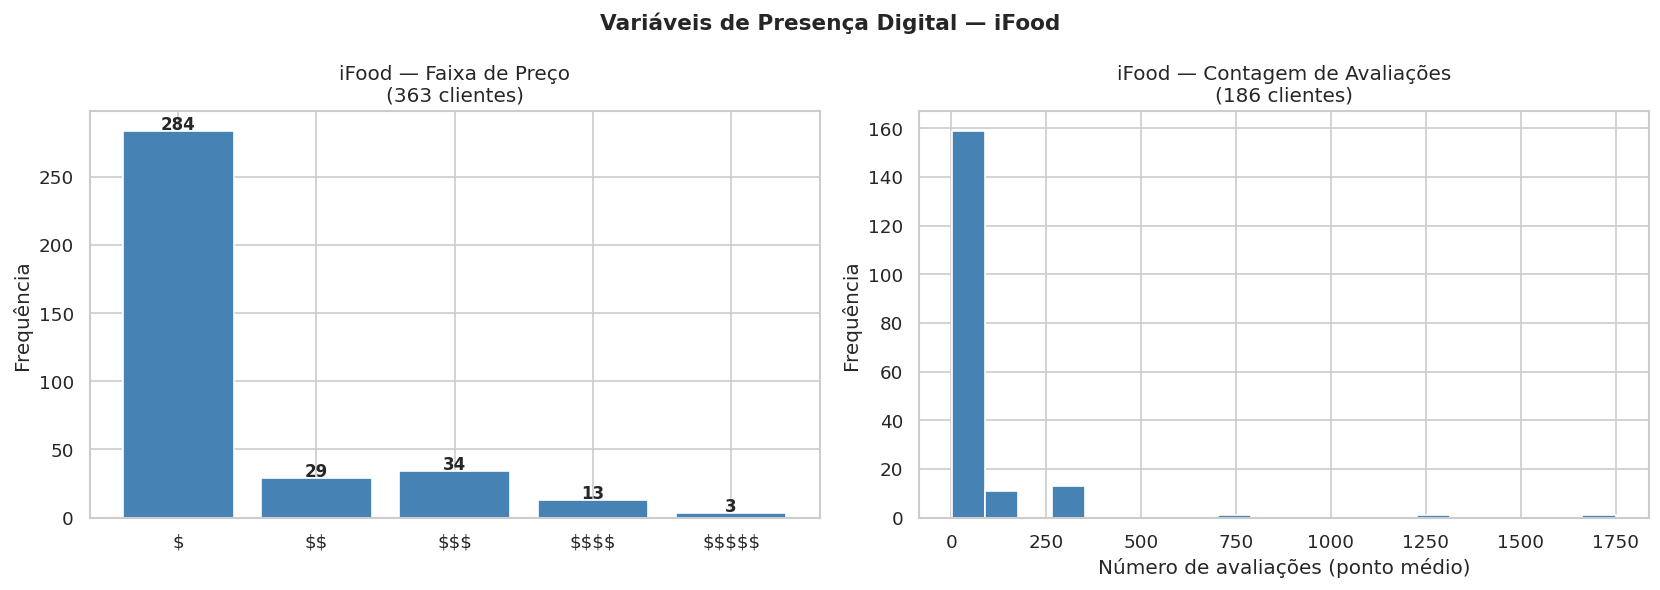


── ifood_contagem_avaliacoes (ponto médio) ──


,count,mean,std,min,25%,50%,75%,max
ifood_contagem_avaliacoes_num,186.0000,72.4731,183.2990,2.5000,2.5000,15.0000,40.0000,1750.0000


In [25]:
# ── iFood ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Faixa de preço — escapar $ para não ativar LaTeX no matplotlib
ordem_preco = ["$", "$$", "$$$", "$$$$", "$$$$$"]
ifood_preco = df["ifood_faixa_preco"].dropna().value_counts().reindex(ordem_preco).dropna()

labels_escapados = [p.replace("$", r"\$") for p in ifood_preco.index]

axes[0].bar(labels_escapados, ifood_preco.values, color="steelblue", edgecolor="white")
axes[0].set_title(f"iFood — Faixa de Preço\n({df['ifood_faixa_preco'].notna().sum()} clientes)")
axes[0].set_ylabel("Frequência")
for i, val in enumerate(ifood_preco.values):
    axes[0].text(i, val + 1, f"{int(val)}", ha="center", fontsize=10, fontweight="bold")

# Contagem de avaliações — agora com ponto médio
ifood_aval = df["ifood_contagem_avaliacoes_num"].dropna()
axes[1].hist(ifood_aval, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title(f"iFood — Contagem de Avaliações\n({len(ifood_aval)} clientes)")
axes[1].set_xlabel("Número de avaliações (ponto médio)")
axes[1].set_ylabel("Frequência")

plt.suptitle("Variáveis de Presença Digital — iFood", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/08_ifood.png",
            bbox_inches="tight")
plt.show()

print(f"\n── ifood_contagem_avaliacoes (ponto médio) ──")
display(ifood_aval.describe().to_frame().T)

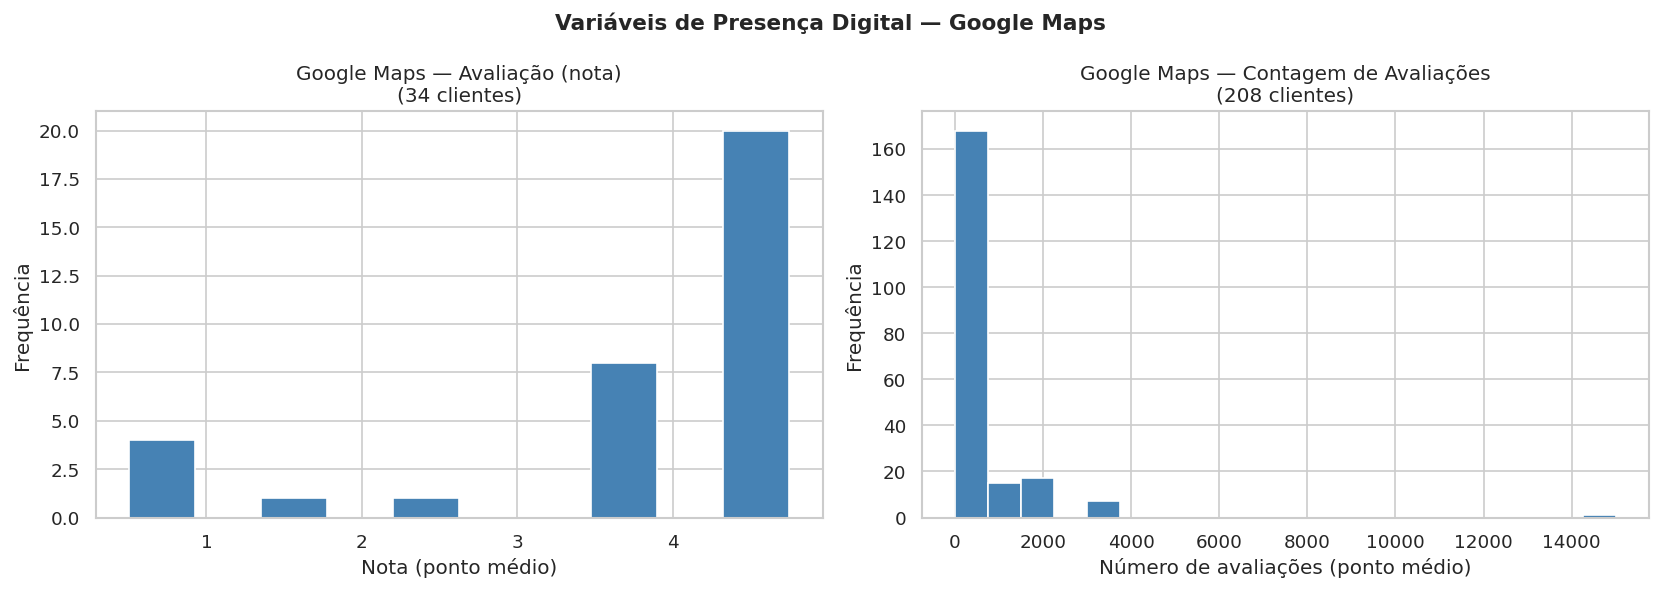


── google_maps_avaliacao (ponto médio) ──


,count,mean,std,min,25%,50%,75%,max
google_maps_avaliacao_num,34.0000,3.7941,1.4492,0.5000,3.5000,4.7500,4.7500,4.7500



── google_maps_contagem_avaliacoes (ponto médio) ──


,count,mean,std,min,25%,50%,75%,max
google_maps_contagem_avaliacoes_num,208.0000,505.5529,1284.4104,2.5000,15.0000,75.0000,400.0000,15000.0000



── google_maps_tem_website ──
Preenchidos: 208
Valor único: [1.]
→ Todos os clientes com presença no Google Maps possuem website.
→ Variável sem variância — não entra no modelo diretamente,
  mas a flag de presença no Google Maps (nulo vs preenchido) pode ter valor.


In [26]:
# ── Google Maps ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avaliação (nota)
gm_nota = df["google_maps_avaliacao_num"].dropna()
axes[0].hist(gm_nota, bins=10, color="steelblue", edgecolor="white")
axes[0].set_title(f"Google Maps — Avaliação (nota)\n({len(gm_nota)} clientes)")
axes[0].set_xlabel("Nota (ponto médio)")
axes[0].set_ylabel("Frequência")

# Contagem de avaliações
gm_contagem = df["google_maps_contagem_avaliacoes_num"].dropna()
axes[1].hist(gm_contagem, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title(f"Google Maps — Contagem de Avaliações\n({len(gm_contagem)} clientes)")
axes[1].set_xlabel("Número de avaliações (ponto médio)")
axes[1].set_ylabel("Frequência")

plt.suptitle("Variáveis de Presença Digital — Google Maps", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/09_google_maps.png",
            bbox_inches="tight")
plt.show()

print(f"\n── google_maps_avaliacao (ponto médio) ──")
display(gm_nota.describe().to_frame().T)

print(f"\n── google_maps_contagem_avaliacoes (ponto médio) ──")
display(gm_contagem.describe().to_frame().T)

# ── google_maps_tem_website ──────────────────────────────────────────────────
print(f"\n── google_maps_tem_website ──")
print(f"Preenchidos: {df['google_maps_tem_website'].notna().sum()}")
print(f"Valor único: {df['google_maps_tem_website'].dropna().unique()}")
print("→ Todos os clientes com presença no Google Maps possuem website.")
print("→ Variável sem variância — não entra no modelo diretamente,")
print("  mas a flag de presença no Google Maps (nulo vs preenchido) pode ter valor.")

In [27]:
# Remover colunas temporárias — serão recriadas no preprocessing
df.drop(columns=["ifood_contagem_avaliacoes_num", "google_maps_avaliacao_num",
                  "google_maps_contagem_avaliacoes_num"], inplace=True)

### Interpretação — Variáveis de Presença Digital

**Observação geral:**
Todas as variáveis numéricas de presença digital estavam codificadas como
intervalos no formato `(X, Y]`, assim como `capital_social` e `idade_cnpj`.
Para análise, foram convertidas ao ponto médio de cada intervalo. As amostras
são muito pequenas em relação à base total (1-12%), o que limita conclusões
estatísticas robustas mas não elimina o valor preditivo dessas variáveis.

**iFood:**
- Apenas 363 clientes (12,1%) possuem `ifood_faixa_preco` preenchido e 186
  (6,2%) possuem `ifood_contagem_avaliacoes`.
- A faixa de preço concentra-se massivamente no nível mais barato: 284 dos
  363 clientes (78,2%) estão na faixa "$", coerente com o perfil de pequenos
  varejistas populares.
- A contagem de avaliações tem distribuição em cauda longa: mediana de 15
  avaliações, mas máximo de 1.750. A grande maioria dos estabelecimentos no
  iFood tem baixo volume de avaliações.

**Google Maps:**
- Apenas 34 clientes (1,1%) possuem `google_maps_avaliacao` preenchido — amostra
  muito pequena para análise univariada confiável. A maioria tem nota alta
  (mediana 4,75), com poucos casos de notas baixas.
- 208 clientes (6,9%) possuem `google_maps_contagem_avaliacoes`, com
  distribuição em cauda longa (mediana 75, máximo 15.000).
- `google_maps_tem_website` possui variância zero: todos os 208 clientes com
  presença no Google Maps possuem website. A variável em si não entra no modelo,
  mas a flag de presença no Google Maps pode ter valor.

**Decisões para o pré-processamento:**
- Criar flags binárias `tem_ifood` e `tem_google_maps` a partir da presença de
  dados — essas flags provavelmente capturam a maior parte do sinal preditivo
  dessas variáveis, dado o alto percentual de nulos.
- As variáveis de valor (notas, contagens, faixas) serão mantidas e convertidas
  ao ponto médio, mas com cautela: amostras de 34 a 363 clientes são frágeis
  para generalização.
- `google_maps_tem_website` será excluída por variância zero.
- O poder preditivo das flags de presença (tem iFood, tem Google Maps) será
  avaliado formalmente na Seção 5 com análise de Information Value (IV) e
  cruzamento direto contra o target.

### 4.5 — cnae_codigo (Classificação Nacional de Atividades Econômicas)

O CNAE é uma variável categórica hierárquica que classifica a atividade econômica
principal do estabelecimento. Embora os códigos estejam anonimizados, a estrutura
hierárquica foi preservada. Um código CNAE como `77.12-5-08` pode ser decomposto em:

| Nível | Exemplo | Significado |
|---|---|---|
| Divisão | `77` | Nível mais amplo da atividade |
| Grupo | `77.12` | Subgrupo dentro da divisão |
| Classe | `77.12-5` | Detalhamento da atividade |
| Subclasse | `77.12-5-08` | Atividade específica (código completo) |

Quanto mais descemos na hierarquia, mais granular a informação — mas maior o risco
de overfitting por baixa representatividade. Vamos analisar a cardinalidade e
distribuição em cada nível.

In [28]:
# Extrair os níveis hierárquicos do CNAE
df["cnae_divisao"] = df["cnae_codigo"].apply(lambda x: str(x).split(".")[0] if pd.notna(x) else np.nan)
df["cnae_grupo"] = df["cnae_codigo"].apply(lambda x: str(x).split("-")[0] if pd.notna(x) else np.nan)
df["cnae_classe"] = df["cnae_codigo"].apply(lambda x: "-".join(str(x).split("-")[:2]) if pd.notna(x) else np.nan)

# Resumo de cardinalidade por nível
print("── Cardinalidade por nível hierárquico ──\n")
niveis = {
    "Subclasse (completo)": "cnae_codigo",
    "Classe": "cnae_classe",
    "Grupo": "cnae_grupo",
    "Divisão": "cnae_divisao"
}

for nome, col in niveis.items():
    n = df[col].nunique()
    print(f"  {nome}: {n} categorias únicas")

print(f"\n  Nulos: {df['cnae_codigo'].isnull().sum()}")

── Cardinalidade por nível hierárquico ──

  Subclasse (completo): 153 categorias únicas
  Classe: 111 categorias únicas
  Grupo: 106 categorias únicas
  Divisão: 39 categorias únicas

  Nulos: 0


In [29]:
# Distribuição no nível de Divisão (mais amplo)
print("── Distribuição por Divisão CNAE ──\n")
divisao_counts = df["cnae_divisao"].value_counts()
display(divisao_counts.to_frame("contagem").assign(
    percentual=lambda x: (x["contagem"] / len(df) * 100).round(2)
))

print(f"\nDivisões com menos de 10 clientes: {(divisao_counts < 10).sum()} de {len(divisao_counts)}")

── Distribuição por Divisão CNAE ──



,contagem,percentual
cnae_divisao,,
53,1420,47.3300
77,1073,35.7700
39,277,9.2300
74,29,0.9700
25,24,0.8000
78,21,0.7000
64,21,0.7000
33,18,0.6000
12,18,0.6000



Divisões com menos de 10 clientes: 28 de 39


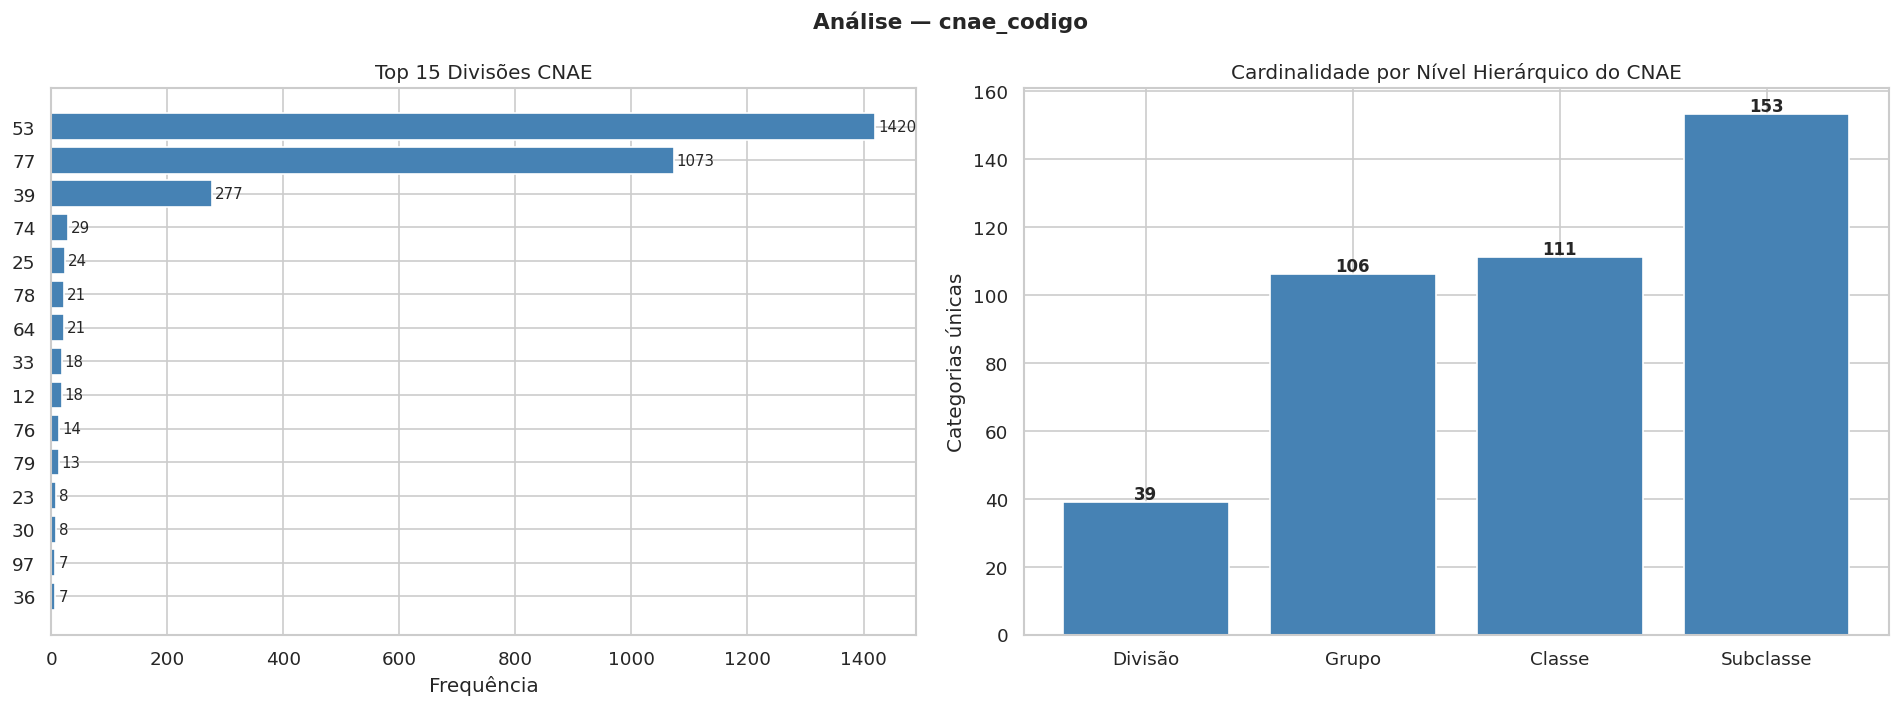

In [30]:
# Visualização — Divisão (nível mais amplo)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 divisões
top_divisoes = divisao_counts.head(15)
axes[0].barh(top_divisoes.index[::-1], top_divisoes.values[::-1],
             color="steelblue", edgecolor="white")
axes[0].set_title("Top 15 Divisões CNAE")
axes[0].set_xlabel("Frequência")
for i, val in enumerate(top_divisoes.values[::-1]):
    axes[0].text(val + 5, i, str(val), va="center", fontsize=9)

# Distribuição da cardinalidade por nível
niveis_card = {
    "Divisão": df["cnae_divisao"].nunique(),
    "Grupo": df["cnae_grupo"].nunique(),
    "Classe": df["cnae_classe"].nunique(),
    "Subclasse": df["cnae_codigo"].nunique()
}

axes[1].bar(niveis_card.keys(), niveis_card.values(),
            color="steelblue", edgecolor="white")
axes[1].set_title("Cardinalidade por Nível Hierárquico do CNAE")
axes[1].set_ylabel("Categorias únicas")
for i, (k, v) in enumerate(niveis_card.items()):
    axes[1].text(i, v + 1, str(v), ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Análise — cnae_codigo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/10_cnae.png",
            bbox_inches="tight")
plt.show()

In [31]:
# Remover colunas temporárias — serão recriadas no preprocessing/feature engineering
df.drop(columns=["cnae_divisao", "cnae_grupo", "cnae_classe"], inplace=True)

### Interpretação — cnae_codigo

**Cardinalidade crescente por nível:**
- Divisão: 39 → Grupo: 106 → Classe: 111 → Subclasse: 153
- O salto de Divisão para Grupo é o mais significativo (39 → 106). De Grupo
  para Classe e Subclasse o ganho de granularidade é menor, sugerindo que o
  nível de Grupo já captura boa parte da diversidade de atividades.

**Concentração extrema em duas divisões:**
- Divisão 53 (47,3%) e Divisão 77 (35,8%) representam juntas 83,1% da base.
  A divisão 39 aparece em terceiro com 9,2%. Todas as demais 36 divisões somam
  apenas 7,7%.
- Esse padrão faz sentido: os códigos são anonimizados, mas provavelmente
  correspondem a atividades de alimentação e comércio varejista — o público
  principal da Praso.

**Alta cardinalidade com baixa representatividade:**
- 28 das 39 divisões possuem menos de 10 clientes, e 14 divisões possuem apenas
  1 cliente cada.
- Nos níveis mais granulares (153 subclasses), o problema se agrava: muitas
  categorias com pouquíssimos exemplos, o que é receita para overfitting.

**Decisões para o pré-processamento e feature engineering:**
- Utilizar o nível de **Divisão** como ponto de partida para o modelo, agrupando
  as divisões com menos de 10 clientes em uma categoria "Outros".
- Testar o nível de **Grupo** se a Divisão se mostrar insuficiente na modelagem.
- Evitar Classe e Subclasse como features diretas — a cardinalidade é alta
  demais para o tamanho da base (153 categorias para 3.000 registros).

## Seção 5 — Análise Bivariada (Feature × Target)

A análise bivariada é o coração da EDA para problemas de classificação. Aqui
cruzamos cada variável com o target (`inadimplente`) para identificar quais
features possuem poder discriminativo — ou seja, quais apresentam distribuições
diferentes entre clientes adimplentes e inadimplentes.

A análise será organizada em:
1. Variáveis numéricas/intervalo × target
2. Variáveis Serasa × target
3. Variáveis categóricas de cadastro × target
4. Variáveis de presença digital × target
5. Information Value (IV) — quantificação formal do poder preditivo

### 5.1 — Variáveis Numéricas × Target

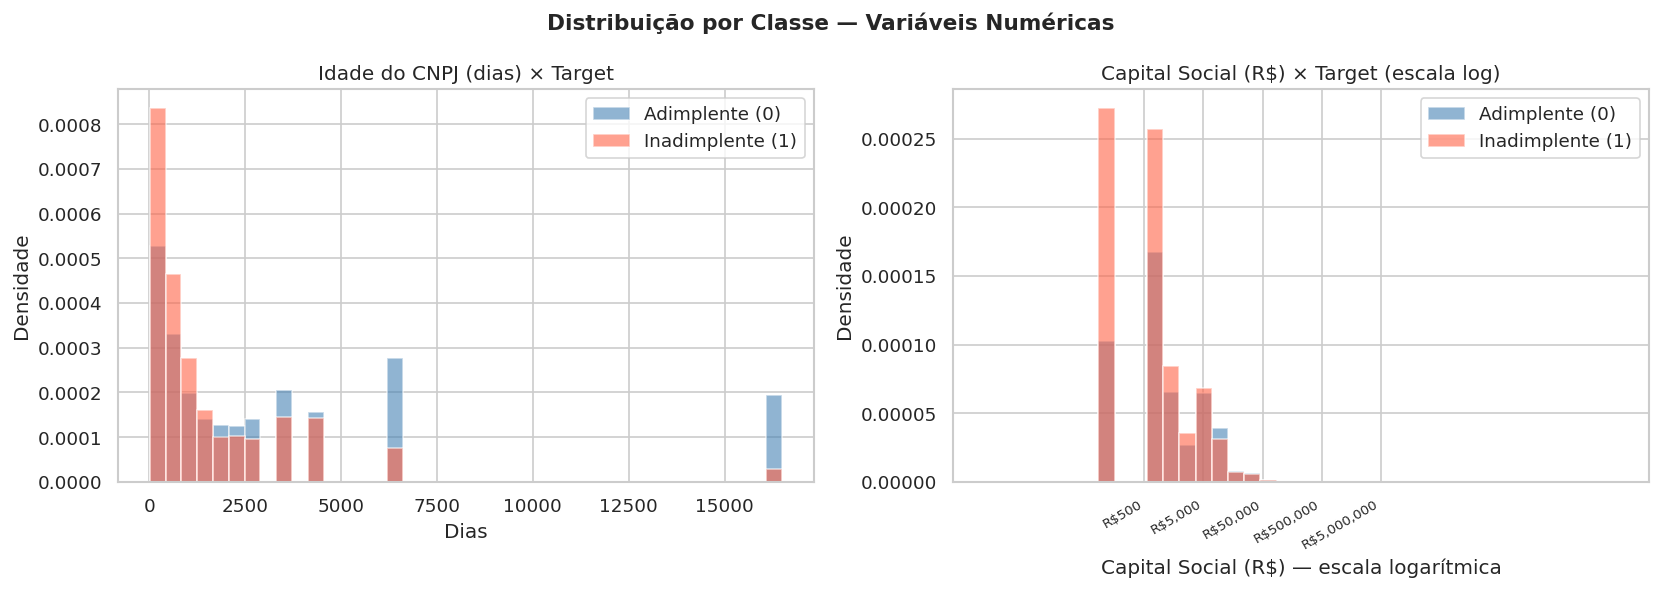

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Idade do CNPJ × Target ───────────────────────────────────────────────────
adimplente_idade = df.loc[df["inadimplente"] == 0, "idade_cnpj_num"].dropna()
inadimplente_idade = df.loc[df["inadimplente"] == 1, "idade_cnpj_num"].dropna()

axes[0].hist(adimplente_idade, bins=40, alpha=0.6, color="steelblue",
             label="Adimplente (0)", density=True, edgecolor="white")
axes[0].hist(inadimplente_idade, bins=40, alpha=0.6, color="tomato",
             label="Inadimplente (1)", density=True, edgecolor="white")
axes[0].set_title("Idade do CNPJ (dias) × Target")
axes[0].set_xlabel("Dias")
axes[0].set_ylabel("Densidade")
axes[0].legend()

# ── Capital Social × Target (escala log) ──────────────────────────────────────
# Filtrar > 0 para escala log
adimplente_cap = df.loc[(df["inadimplente"] == 0) & (df["capital_social_num"] > 0), "capital_social_num"]
inadimplente_cap = df.loc[(df["inadimplente"] == 1) & (df["capital_social_num"] > 0), "capital_social_num"]

bins_log = np.logspace(np.log10(1), np.log10(df["capital_social_num"].max()), 40)

axes[1].hist(adimplente_cap, bins=bins_log, alpha=0.6, color="steelblue",
             label="Adimplente (0)", density=True, edgecolor="white")
axes[1].hist(inadimplente_cap, bins=bins_log, alpha=0.6, color="tomato",
             label="Inadimplente (1)", density=True, edgecolor="white")
axes[1].set_xscale("log")
axes[1].set_title("Capital Social (R$) × Target (escala log)")
axes[1].set_xlabel("Capital Social (R$) — escala logarítmica")
axes[1].set_ylabel("Densidade")
axes[1].legend()

ticks = [500, 5000, 50000, 500000, 5000000]
axes[1].set_xticks(ticks)
axes[1].set_xticklabels([f"R${x:,.0f}" for x in ticks], rotation=30, ha="right", fontsize=8)

plt.suptitle("Distribuição por Classe — Variáveis Numéricas", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/11_numericas_vs_target.png",
            bbox_inches="tight")
plt.show()

In [33]:
variaveis_num = ["idade_cnpj_num", "capital_social_num"]
titulos = ["Idade do CNPJ (dias)", "Capital Social (R$)"]

# Estatísticas descritivas por classe do target
for var, titulo in zip(variaveis_num, titulos):
    print(f"── {titulo} ──")
    resumo = df.groupby("inadimplente")[var].describe()[["mean", "50%", "std"]].T
    resumo.columns = ["Adimplente (0)", "Inadimplente (1)"]
    display(resumo)
    print()

── Idade do CNPJ (dias) ──


,Adimplente (0),Inadimplente (1)
mean,3328.3434,1541.0771
50%,1800.0000,825.0000
std,4378.0346,2245.1038



── Capital Social (R$) ──


,Adimplente (0),Inadimplente (1)
mean,97167647.9791,27310.2431
50%,9000.0000,6500.0000
std,2201874670.5271,84862.3773


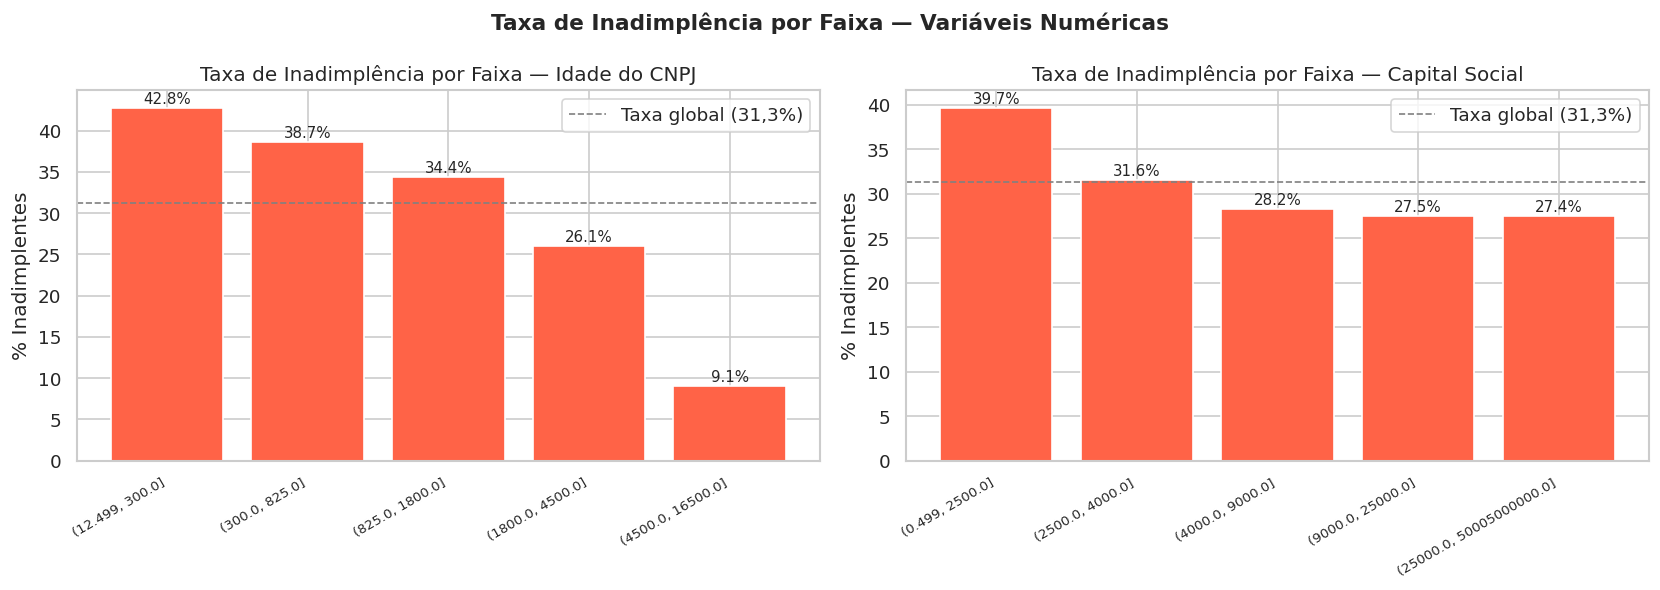

In [34]:
# Taxa de inadimplência por faixa — idade do CNPJ
df["idade_cnpj_faixa"] = pd.qcut(df["idade_cnpj_num"], q=5, duplicates="drop")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Idade do CNPJ
taxa_idade = df.groupby("idade_cnpj_faixa", observed=True)["inadimplente"].mean() * 100
axes[0].bar(range(len(taxa_idade)), taxa_idade.values, color="tomato", edgecolor="white")
axes[0].set_xticks(range(len(taxa_idade)))
axes[0].set_xticklabels([str(x) for x in taxa_idade.index], rotation=30, ha="right", fontsize=8)
axes[0].set_title("Taxa de Inadimplência por Faixa — Idade do CNPJ")
axes[0].set_ylabel("% Inadimplentes")
axes[0].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[0].legend()
for i, val in enumerate(taxa_idade.values):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=9)

# Capital Social — log para criar faixas mais equilibradas
df["capital_social_log_faixa"] = pd.qcut(df["capital_social_num"], q=5, duplicates="drop")

taxa_capital = df.groupby("capital_social_log_faixa", observed=True)["inadimplente"].mean() * 100
axes[1].bar(range(len(taxa_capital)), taxa_capital.values, color="tomato", edgecolor="white")
axes[1].set_xticks(range(len(taxa_capital)))
axes[1].set_xticklabels([str(x) for x in taxa_capital.index], rotation=30, ha="right", fontsize=8)
axes[1].set_title("Taxa de Inadimplência por Faixa — Capital Social")
axes[1].set_ylabel("% Inadimplentes")
axes[1].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[1].legend()
for i, val in enumerate(taxa_capital.values):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=9)

plt.suptitle("Taxa de Inadimplência por Faixa — Variáveis Numéricas",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/12_taxa_inad_numericas.png",
            bbox_inches="tight")
plt.show()

# Limpar colunas temporárias
df.drop(columns=["idade_cnpj_faixa", "capital_social_log_faixa"], inplace=True)

### Interpretação — Variáveis Numéricas × Target

**Idade do CNPJ — feature com alto poder discriminativo:**
- Tendência monotônica clara: quanto mais jovem o CNPJ, maior a taxa de
  inadimplência. Empresas com menos de 300 dias apresentam 42,8% de
  inadimplência, enquanto empresas com mais de 4.500 dias apresentam apenas
  9,1% — uma diferença de 4,7x.
- A mediana confirma a separação: inadimplentes têm mediana de 825 dias (2,3
  anos) contra 1.800 dias (4,9 anos) dos adimplentes.
- No histograma de densidade, a curva dos inadimplentes se concentra mais à
  esquerda (CNPJs jovens), enquanto a dos adimplentes se espalha mais para a
  direita. A separação é visível mas parcial — há sobreposição nas faixas
  intermediárias.
- **Conclusão:** variável promissora para o modelo. A relação com a
  inadimplência é intuitiva e forte.

**Capital Social — sinal presente mas mais fraco:**
- A faixa de menor capital social (até 2.500) apresenta taxa de
  inadimplência de 39,7%, acima da média global. As faixas superiores ficam
  entre 27-28%, mas sem tendência monotônica clara.
- As medianas por classe diferem pouco (9.000 vs 6.500). A média é
  distorcida por outliers extremos nos adimplentes.
- No histograma de densidade, as distribuições se sobrepõem quase
  completamente, indicando baixo poder de separação visual.
- **Conclusão:** o sinal existe mas é mais fraco que a idade do CNPJ.
  Transformação logarítmica e tratamento de outliers no preprocessing podem
  melhorar a capacidade discriminativa.

### 5.2 — Variáveis Serasa × Target

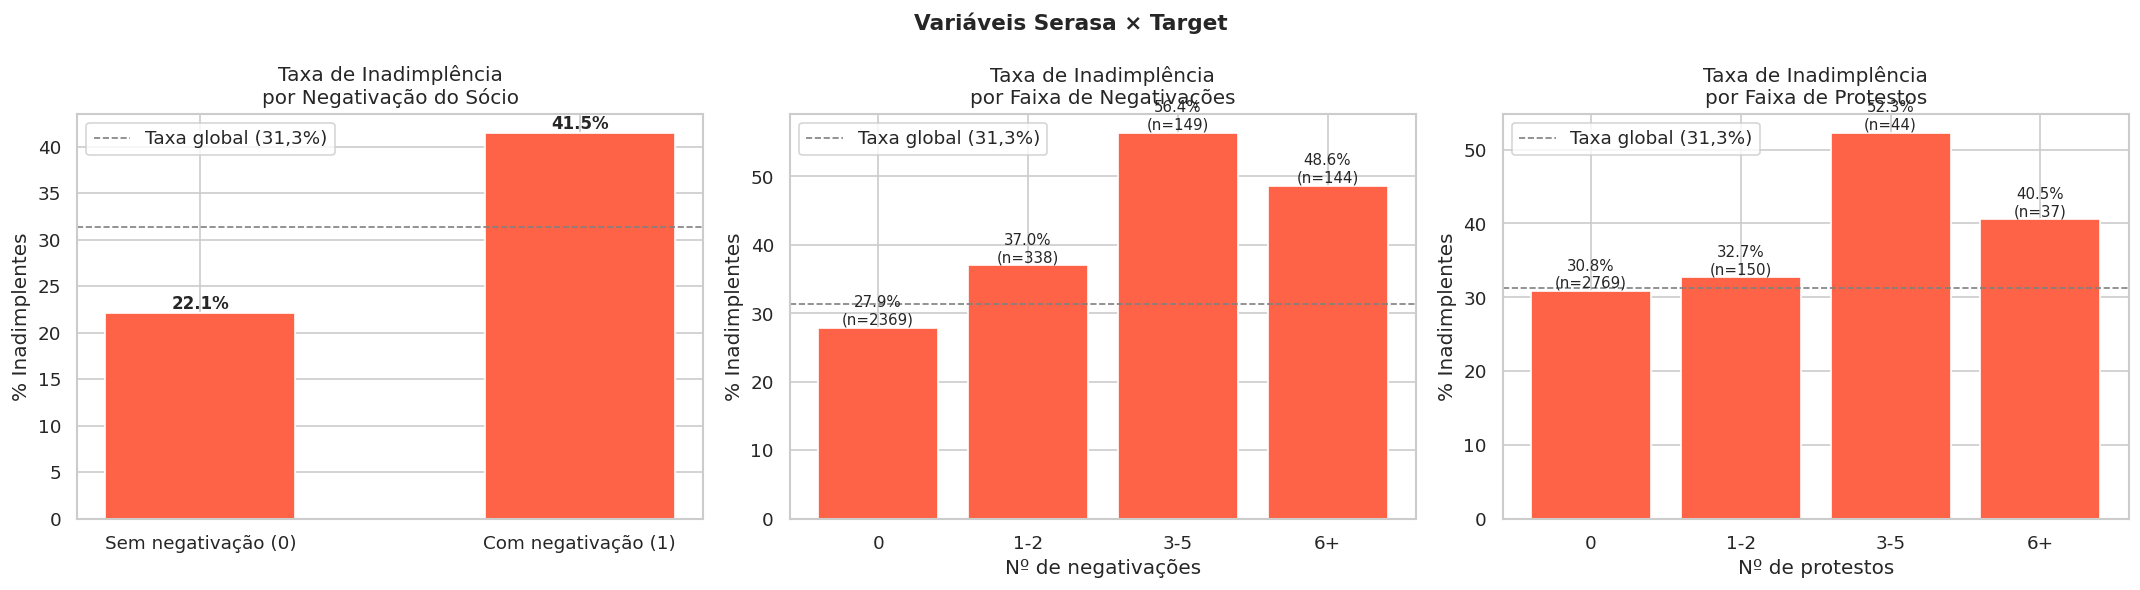

In [35]:
# ── serasa_socio_tem_negativacao × Target ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Taxa de inadimplência por sócio com negativação
taxa_socio = df.groupby("serasa_socio_tem_negativacao")["inadimplente"].mean() * 100
labels_socio = ["Sem negativação (0)", "Com negativação (1)"]

axes[0].bar(labels_socio, taxa_socio.values, color="tomato", edgecolor="white", width=0.5)
axes[0].set_title("Taxa de Inadimplência\npor Negativação do Sócio")
axes[0].set_ylabel("% Inadimplentes")
axes[0].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[0].legend()
for i, val in enumerate(taxa_socio.values):
    axes[0].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

# ── Contagem de negativações × Target ─────────────────────────────────────────
# Criar faixas: 0, 1-2, 3-5, 6+
def faixa_negativacao(val):
    if val == 0: return "0"
    elif val <= 2: return "1-2"
    elif val <= 5: return "3-5"
    else: return "6+"

df["faixa_negativacoes"] = df["serasa_contagem_negativacoes"].apply(faixa_negativacao)
ordem_neg = ["0", "1-2", "3-5", "6+"]

taxa_neg = df.groupby("faixa_negativacoes")["inadimplente"].mean().reindex(ordem_neg) * 100
contagem_neg = df.groupby("faixa_negativacoes")["inadimplente"].count().reindex(ordem_neg)

axes[1].bar(ordem_neg, taxa_neg.values, color="tomato", edgecolor="white")
axes[1].set_title("Taxa de Inadimplência\npor Faixa de Negativações")
axes[1].set_ylabel("% Inadimplentes")
axes[1].set_xlabel("Nº de negativações")
axes[1].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[1].legend()
for i, (val, n) in enumerate(zip(taxa_neg.values, contagem_neg.values)):
    axes[1].text(i, val + 0.5, f"{val:.1f}%\n(n={n})", ha="center", fontsize=9)

# ── Contagem de protestos × Target ────────────────────────────────────────────
def faixa_protestos(val):
    if val == 0: return "0"
    elif val <= 2: return "1-2"
    elif val <= 5: return "3-5"
    else: return "6+"

df["faixa_protestos"] = df["serasa_contagem_protestos"].apply(faixa_protestos)
ordem_prot = ["0", "1-2", "3-5", "6+"]

taxa_prot = df.groupby("faixa_protestos")["inadimplente"].mean().reindex(ordem_prot) * 100
contagem_prot = df.groupby("faixa_protestos")["inadimplente"].count().reindex(ordem_prot)

axes[2].bar(ordem_prot, taxa_prot.values, color="tomato", edgecolor="white")
axes[2].set_title("Taxa de Inadimplência\npor Faixa de Protestos")
axes[2].set_ylabel("% Inadimplentes")
axes[2].set_xlabel("Nº de protestos")
axes[2].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[2].legend()
for i, (val, n) in enumerate(zip(taxa_prot.values, contagem_prot.values)):
    axes[2].text(i, val + 0.5, f"{val:.1f}%\n(n={n})", ha="center", fontsize=9)

plt.suptitle("Variáveis Serasa × Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/13_serasa_vs_target.png",
            bbox_inches="tight")
plt.show()

# Limpar temporárias
df.drop(columns=["faixa_negativacoes", "faixa_protestos"], inplace=True)

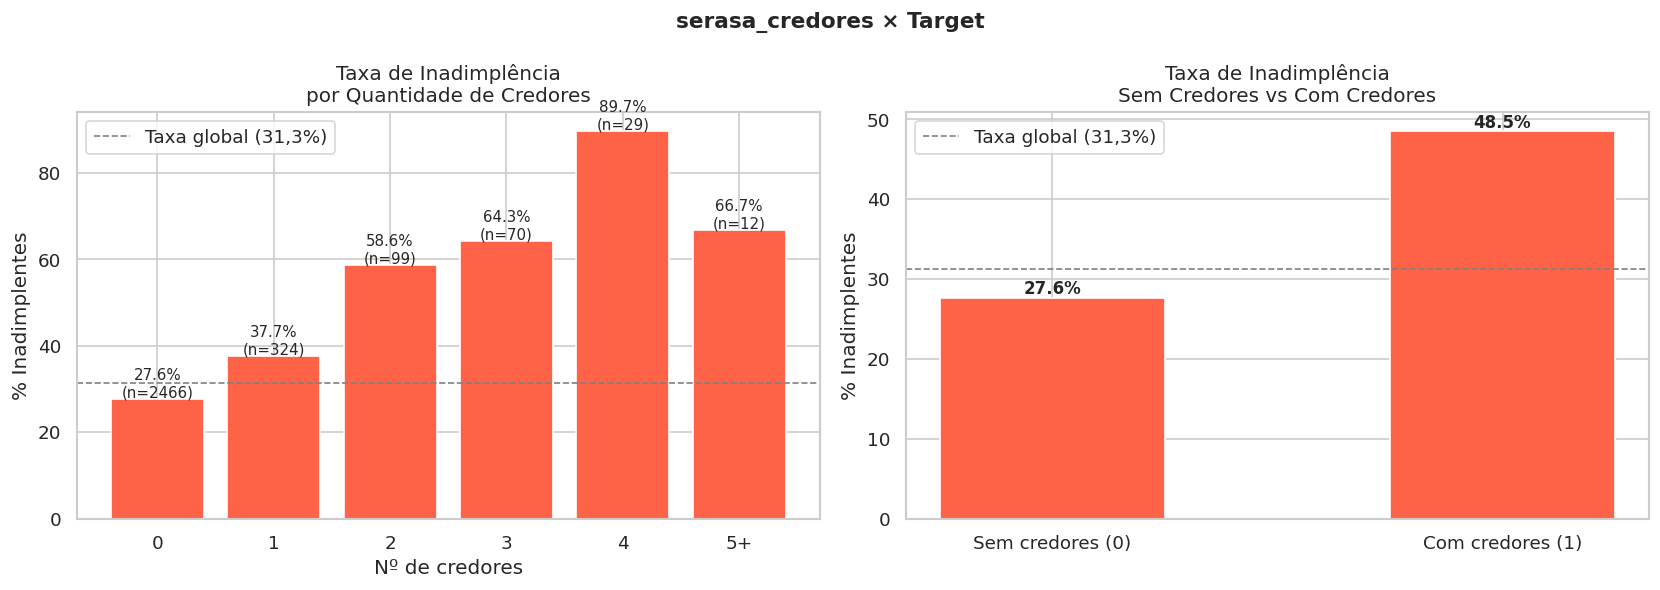

In [36]:
# ── serasa_credores: taxa de inadimplência por quantidade de credores ─────────
df["credores_lista_temp"] = df["serasa_credores"].apply(
    lambda x: [] if pd.isnull(x) else [c.strip() for c in str(x).split(",") if c.strip()]
)
df["qtd_credores_temp"] = df["credores_lista_temp"].apply(len)

# Agrupar 5+ para evitar categorias com poucos casos
df["faixa_credores"] = df["qtd_credores_temp"].apply(
    lambda x: "5+" if x >= 5 else str(x)
)
ordem_cred = ["0", "1", "2", "3", "4", "5+"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taxa de inadimplência por quantidade de credores
taxa_cred = df.groupby("faixa_credores")["inadimplente"].mean().reindex(ordem_cred) * 100
contagem_cred = df.groupby("faixa_credores")["inadimplente"].count().reindex(ordem_cred)

axes[0].bar(ordem_cred, taxa_cred.values, color="tomato", edgecolor="white")
axes[0].set_title("Taxa de Inadimplência\npor Quantidade de Credores")
axes[0].set_ylabel("% Inadimplentes")
axes[0].set_xlabel("Nº de credores")
axes[0].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[0].legend()
for i, (val, n) in enumerate(zip(taxa_cred.values, contagem_cred.values)):
    axes[0].text(i, val + 0.5, f"{val:.1f}%\n(n={n})", ha="center", fontsize=9)

# Taxa de inadimplência: tem credor vs não tem
df["tem_credor"] = (df["qtd_credores_temp"] > 0).astype(int)
taxa_tem_credor = df.groupby("tem_credor")["inadimplente"].mean() * 100
labels_credor = ["Sem credores (0)", "Com credores (1)"]

axes[1].bar(labels_credor, taxa_tem_credor.values, color="tomato", edgecolor="white", width=0.5)
axes[1].set_title("Taxa de Inadimplência\nSem Credores vs Com Credores")
axes[1].set_ylabel("% Inadimplentes")
axes[1].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[1].legend()
for i, val in enumerate(taxa_tem_credor.values):
    axes[1].text(i, val + 0.5, f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("serasa_credores × Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/14_credores_vs_target.png",
            bbox_inches="tight")
plt.show()

# Limpar temporárias
df.drop(columns=["credores_lista_temp", "qtd_credores_temp", "faixa_credores", "tem_credor"], inplace=True)

In [37]:
# Parsing dos segmentos de credores
df["credores_lista_temp"] = df["serasa_credores"].apply(
    lambda x: [] if pd.isnull(x) else [c.strip() for c in str(x).split(",") if c.strip()]
)

# Identificar segmentos com frequência suficiente para análise (>= 10 ocorrências)
from collections import Counter
todos_seg = [seg for lista in df["credores_lista_temp"] for seg in lista]
freq_seg = Counter(todos_seg)
segmentos_validos = [seg for seg, freq in freq_seg.items() if freq >= 10]

print(f"Segmentos com >= 10 ocorrências: {len(segmentos_validos)}\n")

# Para cada segmento: criar flag e calcular taxa de inadimplência
resultados = []
for seg in segmentos_validos:
    df[f"temp_credor_{seg}"] = df["credores_lista_temp"].apply(lambda x: 1 if seg in x else 0)
    tem = df[df[f"temp_credor_{seg}"] == 1]["inadimplente"].mean() * 100
    nao_tem = df[df[f"temp_credor_{seg}"] == 0]["inadimplente"].mean() * 100
    n_tem = df[f"temp_credor_{seg}"].sum()
    resultados.append({
        "segmento": seg,
        "taxa_com_divida (%)": round(tem, 1),
        "taxa_sem_divida (%)": round(nao_tem, 1),
        "diferenca (pp)": round(tem - nao_tem, 1),
        "n_clientes": n_tem
    })
    df.drop(columns=[f"temp_credor_{seg}"], inplace=True)

df_credor_target = (pd.DataFrame(resultados)
                    .sort_values("diferenca (pp)", ascending=False)
                    .reset_index(drop=True))

display(df_credor_target)

Segmentos com >= 10 ocorrências: 12



,segmento,taxa_com_divida (%),taxa_sem_divida (%),diferenca (pp),n_clientes
0,Alimentos e Bebidas,64.8000,29.4000,35.5000,165
1,Distribuição,65.3000,30.5000,34.9000,75
2,Indústria,63.6000,31.2000,32.4000,11
3,Financeiro,62.5000,30.5000,32.0000,80
4,Comércio,62.5000,31.1000,31.4000,24
5,Bancos e Financeiro,57.9000,29.8000,28.1000,164
6,Diversos,53.6000,31.1000,22.4000,28
7,Tecnologia e Pagamentos,43.2000,31.0000,12.2000,88
8,Saúde,42.9000,31.1000,11.7000,56
9,Telecomunicações,40.5000,31.2000,9.3000,42


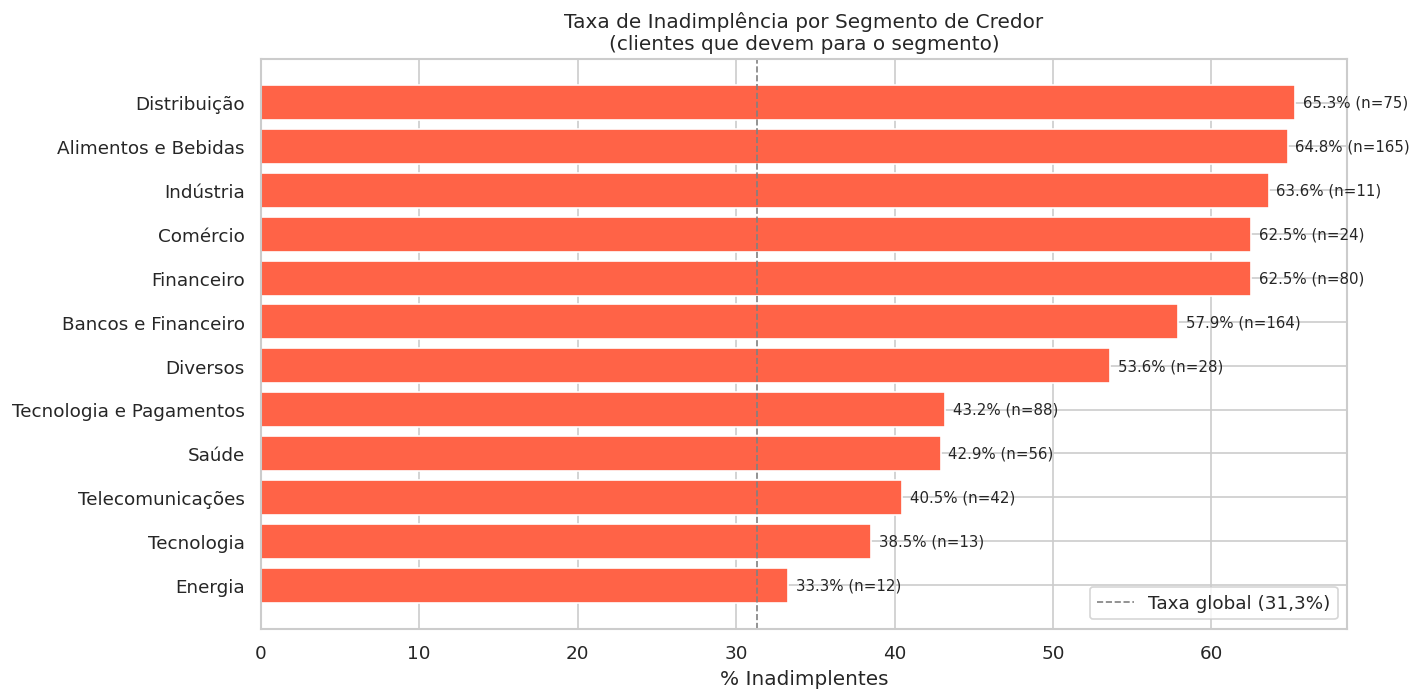

In [38]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plotar taxa de inadimplência por segmento de credor
df_plot = df_credor_target.sort_values("taxa_com_divida (%)", ascending=True)

bars = ax.barh(df_plot["segmento"], df_plot["taxa_com_divida (%)"],
               color="tomato", edgecolor="white")
ax.axvline(x=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
ax.set_title("Taxa de Inadimplência por Segmento de Credor\n(clientes que devem para o segmento)")
ax.set_xlabel("% Inadimplentes")
ax.legend()

for i, (seg, val, n) in enumerate(zip(df_plot["segmento"],
                                       df_plot["taxa_com_divida (%)"],
                                       df_plot["n_clientes"])):
    ax.text(val + 0.5, i, f"{val:.1f}% (n={n})", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/15_credor_segmento_target.png",
            bbox_inches="tight")
plt.show()

# Limpar temporária
df.drop(columns=["credores_lista_temp"], inplace=True)

### Interpretação — Variáveis Serasa × Target

As variáveis Serasa são, até o momento, as **features mais preditivas** do
dataset. Todos os indicadores de crédito apresentam relação clara com a
inadimplência.

**Sócio com negativação (serasa_socio_tem_negativacao):**
- Clientes cujo sócio possui negativação têm taxa de inadimplência de 41,5%,
  contra 22,1% dos que não possuem — quase o dobro.
- Feature binária, completa (sem nulos) e com forte poder discriminativo.

**Contagem de negativações (serasa_contagem_negativacoes):**
- Tendência monotônica clara: de 27,9% (zero negativações) até 56,4% (3-5
  negativações), com leve queda em 6+ (48,6%), possivelmente por saturação
  do risco ou amostra menor (n=144).
- Mesmo a faixa 1-2 (37,0%) já está significativamente acima da taxa global.

**Contagem de protestos (serasa_contagem_protestos):**
- Padrão similar mas com amostras menores. A faixa 3-5 atinge 52,3% (n=44),
  enquanto 6+ alcança 40,5% (n=37). A tendência é menos estável por conta do
  tamanho das amostras, mas a direção é consistente.

**Quantidade de credores (serasa_credores):**
- Relação monotônica muito forte: de 27,6% (zero credores) até 89,7% (4
  credores). Clientes com 4 credores têm inadimplência 3,2x maior que
  clientes sem nenhum.
- A flag binária (tem/não tem credor) já captura boa parte do sinal: 27,6%
  vs 48,5%.

**Segmentos de credores:**
- Todos os segmentos analisados apresentam taxa de inadimplência acima da
  média global (31,3%), o que é esperado — ter qualquer dívida registrada já
  é um indicador de risco.
- Os segmentos com maior taxa são Distribuição (65,3%), Alimentos e Bebidas
  (64,8%) e Indústria (63,6%) — dívidas com fornecedores do próprio setor
  varejista indicam maior risco.
- Os segmentos com menor impacto relativo são Energia (33,3%) e Tecnologia
  (38,5%) — possivelmente dívidas operacionais menos correlacionadas com
  dificuldade financeira generalizada.
- A diferença em pontos percentuais entre dever e não dever para um segmento
  varia de 2,0 pp (Energia) a 35,5 pp (Alimentos e Bebidas), demonstrando
  que o tipo de credor carrega informação adicional além da simples presença
  de dívida.

### 5.3 — Variáveis Categóricas de Cadastro × Target

Excluímos `uf` desta análise pois possui variância zero (100% CE).

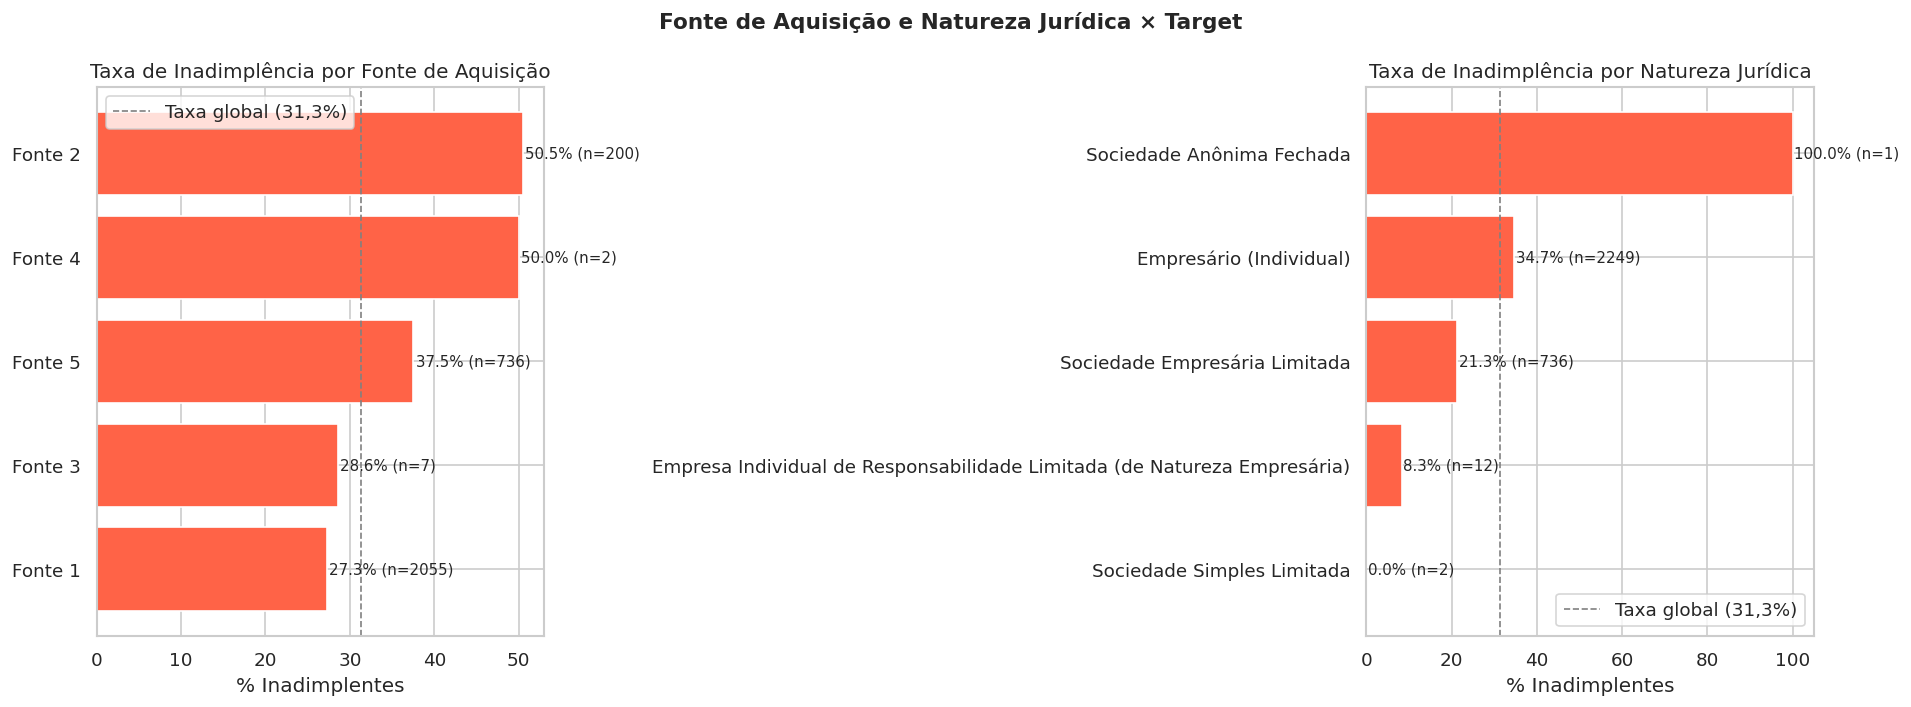

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Fonte Cliente × Target ───────────────────────────────────────────────────
taxa_fonte = df.groupby("fonte_cliente")["inadimplente"].agg(["mean", "count"])
taxa_fonte["mean"] = taxa_fonte["mean"] * 100
taxa_fonte = taxa_fonte.sort_values("mean", ascending=True)

axes[0].barh(taxa_fonte.index, taxa_fonte["mean"], color="tomato", edgecolor="white")
axes[0].axvline(x=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[0].set_title("Taxa de Inadimplência por Fonte de Aquisição")
axes[0].set_xlabel("% Inadimplentes")
axes[0].legend()
for i, (idx, row) in enumerate(taxa_fonte.iterrows()):
    axes[0].text(row["mean"] + 0.3, i, f'{row["mean"]:.1f}% (n={int(row["count"])})',
                 va="center", fontsize=9)

# ── Natureza Jurídica × Target ────────────────────────────────────────────────
taxa_nat = df.groupby("natureza_juridica")["inadimplente"].agg(["mean", "count"])
taxa_nat["mean"] = taxa_nat["mean"] * 100
taxa_nat = taxa_nat.sort_values("mean", ascending=True)

labels_nat = [label.split(" - ")[1] if " - " in label else label for label in taxa_nat.index]

axes[1].barh(labels_nat, taxa_nat["mean"], color="tomato", edgecolor="white")
axes[1].axvline(x=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[1].set_title("Taxa de Inadimplência por Natureza Jurídica")
axes[1].set_xlabel("% Inadimplentes")
axes[1].legend()
for i, (idx, row) in enumerate(taxa_nat.iterrows()):
    axes[1].text(row["mean"] + 0.3, i, f'{row["mean"]:.1f}% (n={int(row["count"])})',
                 va="center", fontsize=9)

plt.suptitle("Fonte de Aquisição e Natureza Jurídica × Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/16a_fonte_natureza_vs_target.png",
            bbox_inches="tight")
plt.show()

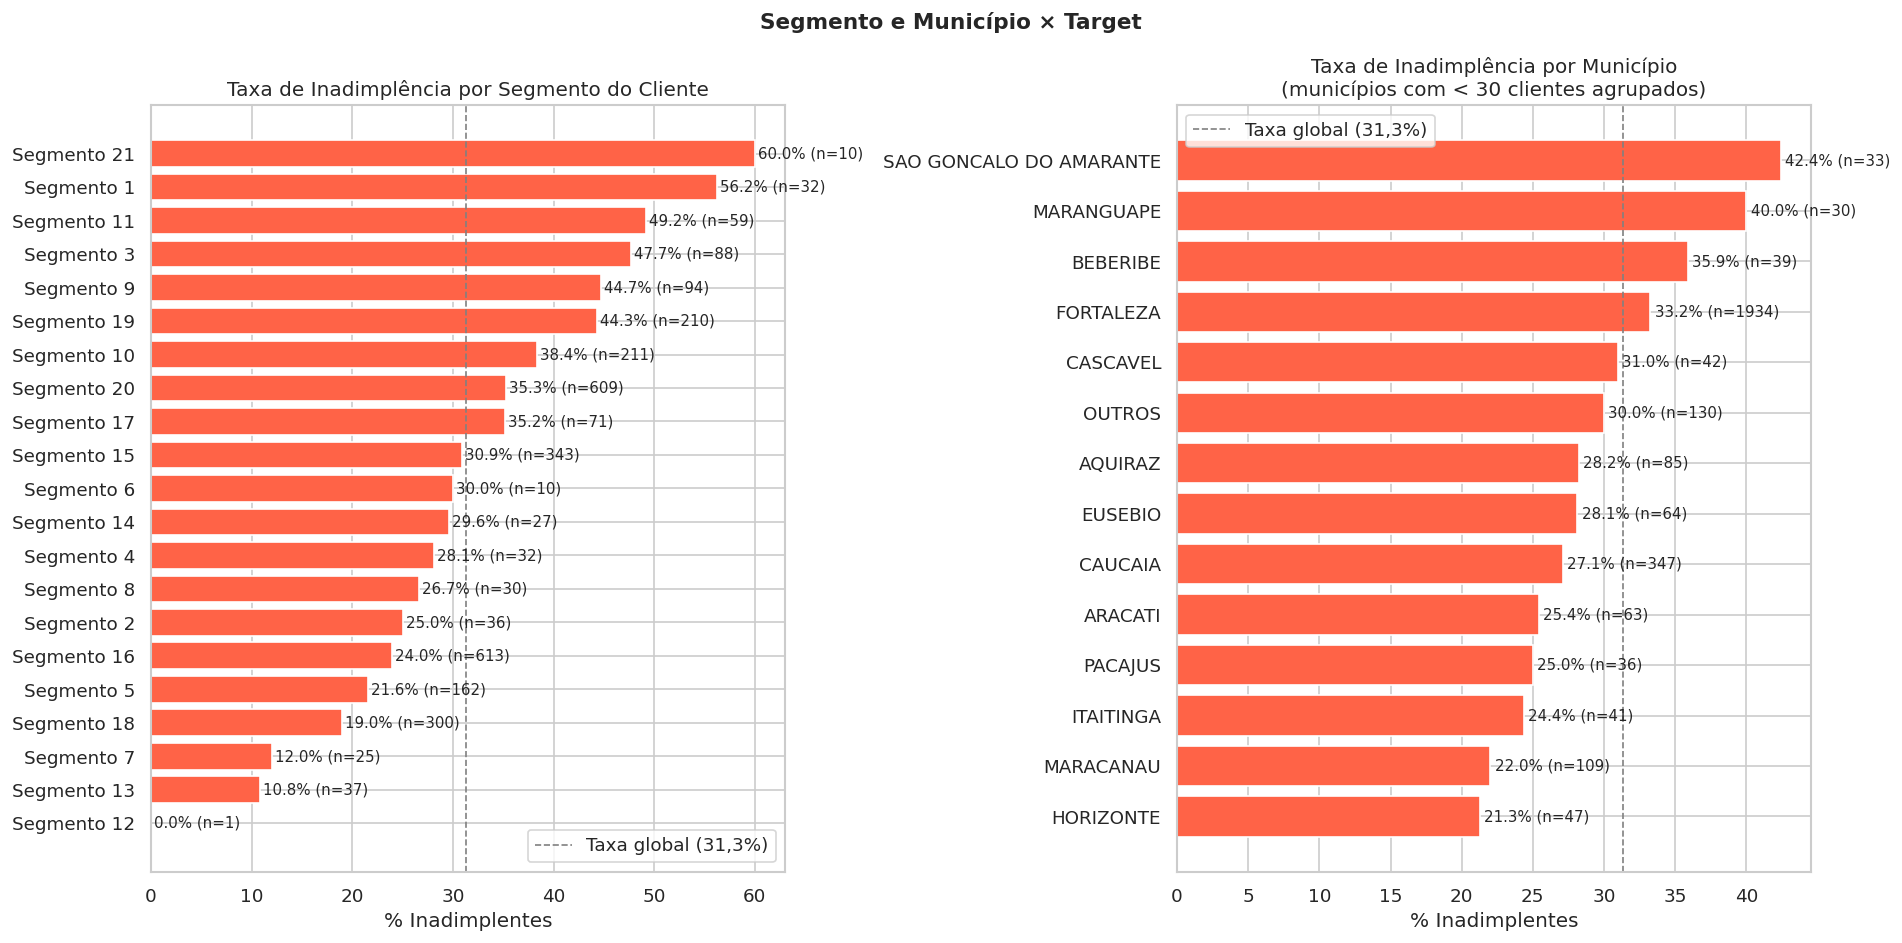

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Segmento Cliente × Target ────────────────────────────────────────────────
taxa_seg = df.groupby("segmento_cliente")["inadimplente"].agg(["mean", "count"])
taxa_seg["mean"] = taxa_seg["mean"] * 100
taxa_seg = taxa_seg.sort_values("mean", ascending=True)

axes[0].barh(taxa_seg.index, taxa_seg["mean"], color="tomato", edgecolor="white")
axes[0].axvline(x=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[0].set_title("Taxa de Inadimplência por Segmento do Cliente")
axes[0].set_xlabel("% Inadimplentes")
axes[0].legend()
for i, (idx, row) in enumerate(taxa_seg.iterrows()):
    axes[0].text(row["mean"] + 0.3, i, f'{row["mean"]:.1f}% (n={int(row["count"])})',
                 va="center", fontsize=9)

# ── Município × Target ───────────────────────────────────────────────────────
contagem_mun = df["municipio"].value_counts()
mun_validos = contagem_mun[contagem_mun >= 30].index
df["municipio_agrupado"] = df["municipio"].apply(lambda x: x if x in mun_validos else "OUTROS")

taxa_mun = df.groupby("municipio_agrupado")["inadimplente"].agg(["mean", "count"])
taxa_mun["mean"] = taxa_mun["mean"] * 100
taxa_mun = taxa_mun.sort_values("mean", ascending=True)

axes[1].barh(taxa_mun.index, taxa_mun["mean"], color="tomato", edgecolor="white")
axes[1].axvline(x=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[1].set_title("Taxa de Inadimplência por Município\n(municípios com < 30 clientes agrupados)")
axes[1].set_xlabel("% Inadimplentes")
axes[1].legend()
for i, (idx, row) in enumerate(taxa_mun.iterrows()):
    axes[1].text(row["mean"] + 0.3, i, f'{row["mean"]:.1f}% (n={int(row["count"])})',
                 va="center", fontsize=9)

plt.suptitle("Segmento e Município × Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/16b_segmento_municipio_vs_target.png",
            bbox_inches="tight")
plt.show()

# Limpar temporária
df.drop(columns=["municipio_agrupado"], inplace=True)

### Interpretação — Variáveis Categóricas de Cadastro × Target

**Fonte de Aquisição (fonte_cliente):**
- Fonte 2 apresenta a maior taxa de inadimplência (50,5%, n=200) — muito acima
  da média global e com amostra relevante. Fonte 5 também está acima (37,5%,
  n=736).
- Fonte 1, a mais frequente (n=2.055), fica abaixo da média global com 27,3%.
- Fonte 3 (n=7) e Fonte 4 (n=2) têm amostras insuficientes para qualquer
  conclusão — suas taxas são instáveis e não devem ser interpretadas.
- **Conclusão:** feature com sinal moderado. A diferença entre Fonte 1 (27,3%)
  e Fonte 2 (50,5%) é expressiva e com amostras suficientes para confiar.

**Natureza Jurídica (natureza_juridica):**
- Empresário Individual (34,7%, n=2.249) tem inadimplência significativamente
  maior que Sociedade Empresária Limitada (21,3%, n=736) — diferença de 13,4 pp
  com amostras robustas nas duas categorias.
- As demais categorias (EIRELI n=12, Sociedade Simples n=2, S.A. Fechada n=1)
  possuem amostras muito pequenas — taxas extremas como 0% e 100% são artefatos
  do tamanho da amostra e não representam padrão real.
- **Conclusão:** feature útil, mas na prática funciona como binária (EI vs Ltda).
  As categorias residuais devem ser agrupadas no preprocessing.

**Segmento do Cliente (segmento_cliente):**
- Variação expressiva: de 0% (Segmento 12, n=1) a 60% (Segmento 21, n=10).
- Porém, os extremos são dominados por segmentos com amostras muito pequenas.
  Segmentos com n < 30 (como 21, 1, 12, 6, 7) têm taxas instáveis — um cliente
  a mais ou a menos muda a taxa drasticamente.
- Entre os segmentos com amostra relevante (n > 50): Segmento 19 (44,3%, n=210)
  e Segmento 11 (49,2%, n=59) se destacam como mais arriscados, enquanto
  Segmento 18 (19,0%, n=300) e Segmento 16 (24,0%, n=613) são os mais seguros.
- **Conclusão:** feature com poder discriminativo real, mas exige cautela com
  categorias de baixa representatividade para evitar overfitting.

**Município:**
- São Gonçalo do Amarante (42,4%, n=33) e Maranguapé (40,0%, n=30) lideram,
  mas com amostras no limite do confiável.
- Fortaleza (33,2%, n=1.934) fica ligeiramente acima da média global — como
  concentra 64,5% da base, sua taxa acaba próxima da global por peso
  estatístico.
- Horizonte (21,3%, n=47) e Maracanaú (22,0%, n=109) têm as menores taxas,
  com amostras razoáveis.
- **Conclusão:** há variação geográfica moderada, mas a alta concentração em
  Fortaleza e as amostras pequenas nos demais municípios limitam o poder
  preditivo individual. O agrupamento em "Fortaleza", "Região Metropolitana"
  e "Interior" pode ser mais robusto.

**Nota sobre amostras pequenas:**
Várias categorias extremas nesta seção (Fonte 4 com n=2, Segmento 12 com n=1,
S.A. Fechada com n=1) apresentam taxas de 0% ou 100% que são puramente
artefatos do tamanho da amostra. Estas categorias serão agrupadas no
preprocessing e não devem ser interpretadas como padrões reais de risco.

### 5.4 — Variáveis de Presença Digital × Target

A análise aqui foca em dois ângulos distintos:
1. **Presença na plataforma** (ter ou não ter dado) × inadimplência
2. **Valor das variáveis** (faixa de preço, nota, contagem) × inadimplência —
   restrito apenas aos clientes presentes na plataforma

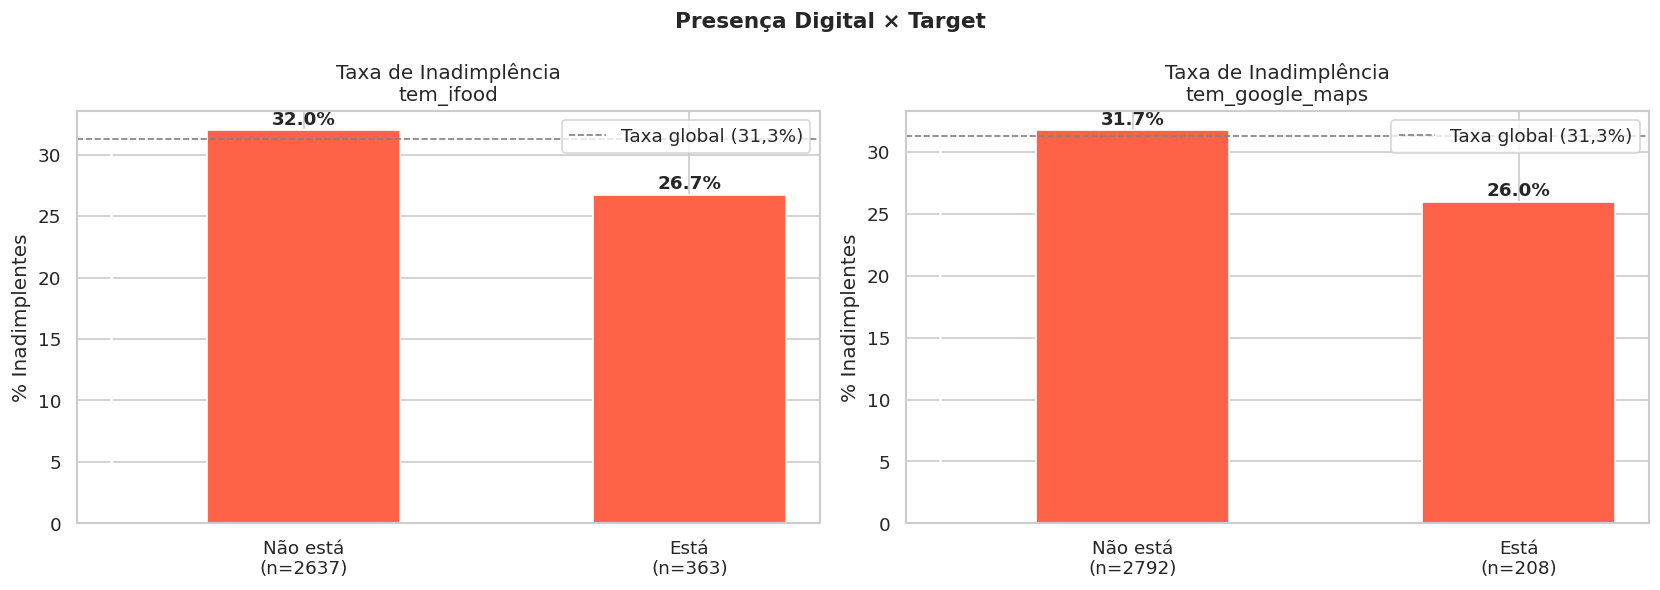

In [41]:
# ── Flags de presença × Target ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

flags = {
    "tem_ifood": df["ifood_faixa_preco"].notna().astype(int),
    "tem_google_maps": df["google_maps_tem_website"].notna().astype(int)
}

for i, (nome, flag) in enumerate(flags.items()):
    df_temp = df.copy()
    df_temp[nome] = flag
    taxa = df_temp.groupby(nome)["inadimplente"].mean() * 100
    contagem = df_temp.groupby(nome)["inadimplente"].count()

    labels = [f"Não está\n(n={contagem[0]})", f"Está\n(n={contagem[1]})"]
    axes[i].bar(labels, taxa.values, color="tomato", edgecolor="white", width=0.5)
    axes[i].axvline(x=-0.5, color="white")
    axes[i].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
    axes[i].set_title(f"Taxa de Inadimplência\n{nome}")
    axes[i].set_ylabel("% Inadimplentes")
    axes[i].legend()
    for j, (val, n) in enumerate(zip(taxa.values, contagem.values)):
        axes[i].text(j, val + 0.5, f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

plt.suptitle("Presença Digital × Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/17a_presenca_digital_target.png",
            bbox_inches="tight")
plt.show()

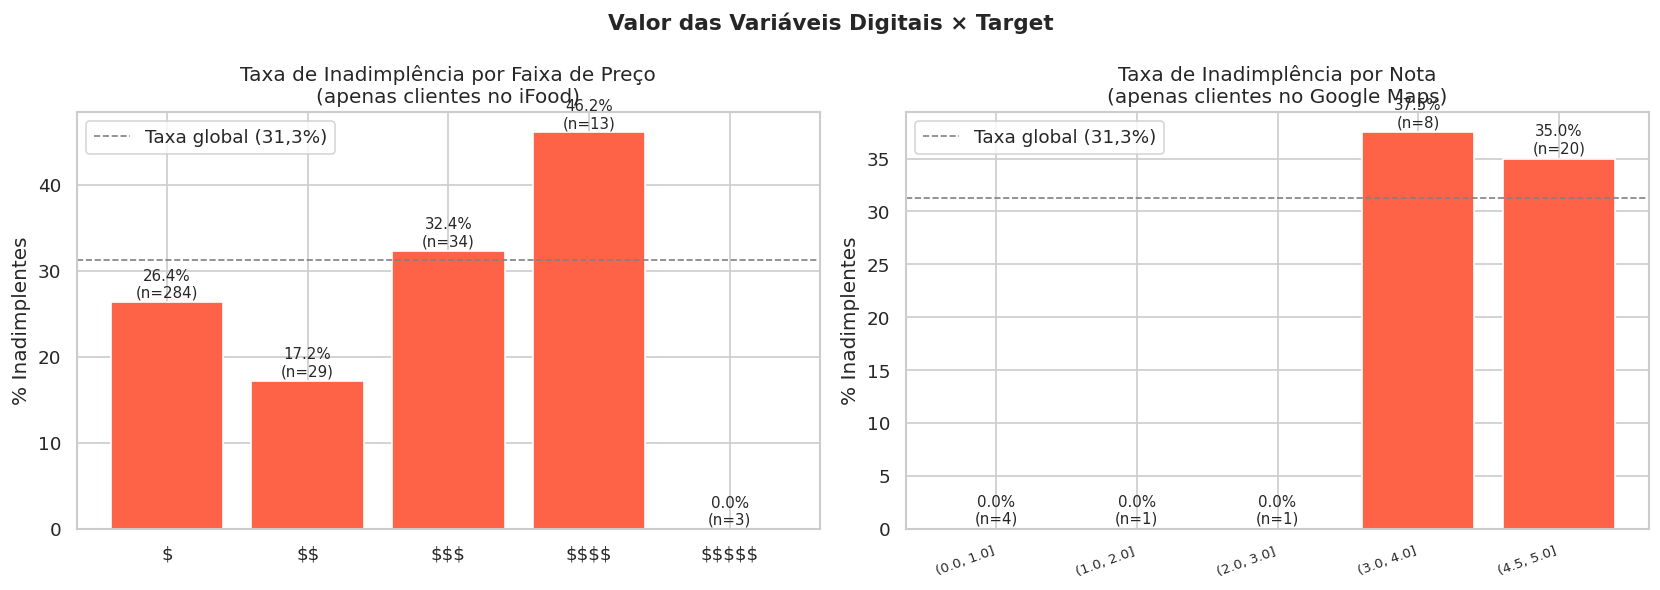

In [42]:
# ── Valor das variáveis × Target (apenas clientes presentes) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# iFood — faixa de preço × Target
df_ifood = df[df["ifood_faixa_preco"].notna()].copy()
ordem_preco = ["$", "$$", "$$$", "$$$$", "$$$$$"]
taxa_preco = df_ifood.groupby("ifood_faixa_preco")["inadimplente"].agg(["mean", "count"])
taxa_preco["mean"] = taxa_preco["mean"] * 100
taxa_preco = taxa_preco.reindex(ordem_preco).dropna()

labels_preco = [p.replace("$", r"\$") for p in taxa_preco.index]
axes[0].bar(labels_preco, taxa_preco["mean"], color="tomato", edgecolor="white")
axes[0].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[0].set_title("Taxa de Inadimplência por Faixa de Preço\n(apenas clientes no iFood)")
axes[0].set_ylabel("% Inadimplentes")
axes[0].legend()
for i, (val, n) in enumerate(zip(taxa_preco["mean"], taxa_preco["count"])):
    axes[0].text(i, val + 0.5, f"{val:.1f}%\n(n={int(n)})", ha="center", fontsize=9)

# Google Maps — nota × Target
df_gm = df[df["google_maps_avaliacao"].notna()].copy()
df_gm["gm_nota_num"] = intervalo_para_ponto_medio(df_gm["google_maps_avaliacao"])

taxa_nota = df_gm.groupby("google_maps_avaliacao")["inadimplente"].agg(["mean", "count"])
taxa_nota["mean"] = taxa_nota["mean"] * 100
taxa_nota = taxa_nota.sort_index()

axes[1].bar(range(len(taxa_nota)), taxa_nota["mean"], color="tomato", edgecolor="white")
axes[1].set_xticks(range(len(taxa_nota)))
axes[1].set_xticklabels(taxa_nota.index, rotation=20, ha="right", fontsize=8)
axes[1].axhline(y=31.3, color="gray", linestyle="--", linewidth=1, label="Taxa global (31,3%)")
axes[1].set_title("Taxa de Inadimplência por Nota\n(apenas clientes no Google Maps)")
axes[1].set_ylabel("% Inadimplentes")
axes[1].legend()
for i, (val, n) in enumerate(zip(taxa_nota["mean"], taxa_nota["count"])):
    axes[1].text(i, val + 0.5, f"{val:.1f}%\n(n={int(n)})", ha="center", fontsize=9)

plt.suptitle("Valor das Variáveis Digitais × Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/17b_valor_digital_target.png",
            bbox_inches="tight")
plt.show()

### Interpretação — Variáveis de Presença Digital × Target

**Flags de presença (tem_ifood, tem_google_maps):**
- Clientes presentes no iFood têm inadimplência de 26,7% vs 32,0% dos ausentes
  — diferença de 5,3 pp abaixo da taxa global.
- Clientes presentes no Google Maps têm 26,0% vs 31,7% dos ausentes —
  diferença de 5,7 pp.
- A presença digital está associada a menor risco, o que é intuitivo:
  estabelecimentos com perfil digital ativo tendem a ser mais estruturados
  e consolidados. Porém, a diferença é modesta comparada às variáveis Serasa.
- O grupo "não está" domina estatisticamente (88-93% da base), fazendo sua
  taxa ficar naturalmente próxima da taxa global — o que não deve ser
  interpretado como ausência de efeito, mas sim como reflexo da distribuição
  da base.

**iFood — faixa de preço:**
- Não há tendência monotônica clara. A faixa mais barata (1 cifrão, n=284)
  tem 26,4% e a faixa seguinte (2 cifrões, n=29) tem 17,2% — ambas abaixo
  da média global.
- A faixa de 4 cifrões sobe para 46,2%, mas com amostra pequena (n=13).
- As faixas mais caras (4 e 5 cifrões) têm amostras muito pequenas —
  taxas instáveis, sem poder de generalização.

**Google Maps — nota:**
- Apenas 34 clientes possuem nota no Google Maps — amostra insuficiente
  para qualquer conclusão robusta.
- As faixas de nota baixa (0 a 3) têm zero inadimplentes, mas com n=4,
  n=1 e n=1 — resultado puramente aleatório.

**Conclusão geral:**
As variáveis de presença digital têm sinal fraco e amostras pequenas.
A flag de presença (tem_ifood, tem_google_maps) captura o sinal disponível,
mas com poder preditivo modesto. O Information Value (IV) na próxima seção
quantificará formalmente essa contribuição antes de decidir sobre a inclusão
ou exclusão dessas variáveis no modelo.

### 5.5 — Information Value (IV)

O Information Value (IV) é uma métrica clássica de credit scoring que quantifica
o poder preditivo de uma variável em relação ao target binário. É baseado no
conceito de Weight of Evidence (WoE), que mede o quanto cada categoria de uma
variável separa clientes bons (adimplentes) de clientes maus (inadimplentes).

| IV | Poder Preditivo |
|---|---|
| < 0,02 | Inútil |
| 0,02 – 0,10 | Fraco |
| 0,10 – 0,30 | Médio |
| 0,30 – 0,50 | Forte |
| > 0,50 | Muito Forte (verificar suspeita de leakage) |

In [43]:
import numpy as np

def calcular_iv(df, coluna, target="inadimplente", bins=10, is_continua=False):
    """
    Calcula o Information Value (IV) de uma variável em relação ao target.
    Para variáveis contínuas, faz binning automático via qcut.
    Para variáveis categóricas, usa os valores originais.
    """
    df_temp = df[[coluna, target]].copy().dropna()

    if is_continua:
        try:
            df_temp["bin"] = pd.qcut(df_temp[coluna], q=bins, duplicates="drop")
        except Exception:
            df_temp["bin"] = pd.cut(df_temp[coluna], bins=bins, duplicates="drop")
    else:
        df_temp["bin"] = df_temp[coluna]

    total_bons = (df_temp[target] == 0).sum()
    total_maus = (df_temp[target] == 1).sum()

    agrupado = df_temp.groupby("bin", observed=True)[target].agg(
        bons=lambda x: (x == 0).sum(),
        maus=lambda x: (x == 1).sum()
    ).reset_index()

    # Laplace smoothing para evitar log(0)
    agrupado["bons"] = agrupado["bons"].replace(0, 0.5)
    agrupado["maus"] = agrupado["maus"].replace(0, 0.5)

    agrupado["prop_bons"] = agrupado["bons"] / total_bons
    agrupado["prop_maus"] = agrupado["maus"] / total_maus
    agrupado["woe"] = np.log(agrupado["prop_bons"] / agrupado["prop_maus"])
    agrupado["iv_parcial"] = (agrupado["prop_bons"] - agrupado["prop_maus"]) * agrupado["woe"]

    return agrupado["iv_parcial"].sum()


# ── Calcular IV para todas as variáveis ───────────────────────────────────────

# Recriar colunas numéricas temporárias
df["capital_social_num"] = intervalo_para_ponto_medio(df["capital_social"])
df["idade_cnpj_num"] = intervalo_para_ponto_medio(df["idade_cnpj"])

# Flags de presença digital
df["tem_ifood"] = df["ifood_faixa_preco"].notna().astype(float)
df["tem_google_maps"] = df["google_maps_tem_website"].notna().astype(float)

# Quantidade de credores
df["qtd_credores"] = df["serasa_credores"].apply(
    lambda x: 0 if pd.isnull(x) else len([c for c in str(x).split(",") if c.strip()])
)

variaveis_iv = {
    # Contínuas
    "idade_cnpj_num":                  True,
    "capital_social_num":              True,
    "serasa_contagem_negativacoes":    True,
    "serasa_contagem_protestos":       True,
    "qtd_credores":                    True,
    # Categóricas / binárias
    "serasa_socio_tem_negativacao":    False,
    "tem_ifood":                       False,
    "tem_google_maps":                 False,
    "fonte_cliente":                   False,
    "natureza_juridica":               False,
    "segmento_cliente":                False,
    "municipio":                       False,
    "ifood_faixa_preco":               False,
}

resultados_iv = []
for col, is_continua in variaveis_iv.items():
    iv = calcular_iv(df, col, is_continua=is_continua)
    if iv < 0.02:
        poder = "Inútil"
    elif iv < 0.10:
        poder = "Fraco"
    elif iv < 0.30:
        poder = "Médio"
    elif iv < 0.50:
        poder = "Forte"
    else:
        poder = "Muito Forte"

    resultados_iv.append({
        "variavel": col,
        "IV": round(iv, 4),
        "poder_preditivo": poder
    })

df_iv = (pd.DataFrame(resultados_iv)
         .sort_values("IV", ascending=False)
         .reset_index(drop=True))

display(df_iv)

# Limpar temporárias
df.drop(columns=["capital_social_num", "idade_cnpj_num",
                  "tem_ifood", "tem_google_maps", "qtd_credores"], inplace=True)

,variavel,IV,poder_preditivo
0,idade_cnpj_num,0.3651,Forte
1,serasa_socio_tem_negativacao,0.2053,Médio
2,segmento_cliente,0.1978,Médio
3,qtd_credores,0.1694,Médio
4,serasa_contagem_negativacoes,0.0972,Fraco
5,fonte_cliente,0.0932,Fraco
6,natureza_juridica,0.0859,Fraco
7,ifood_faixa_preco,0.0643,Fraco
8,municipio,0.0624,Fraco
9,capital_social_num,0.0569,Fraco


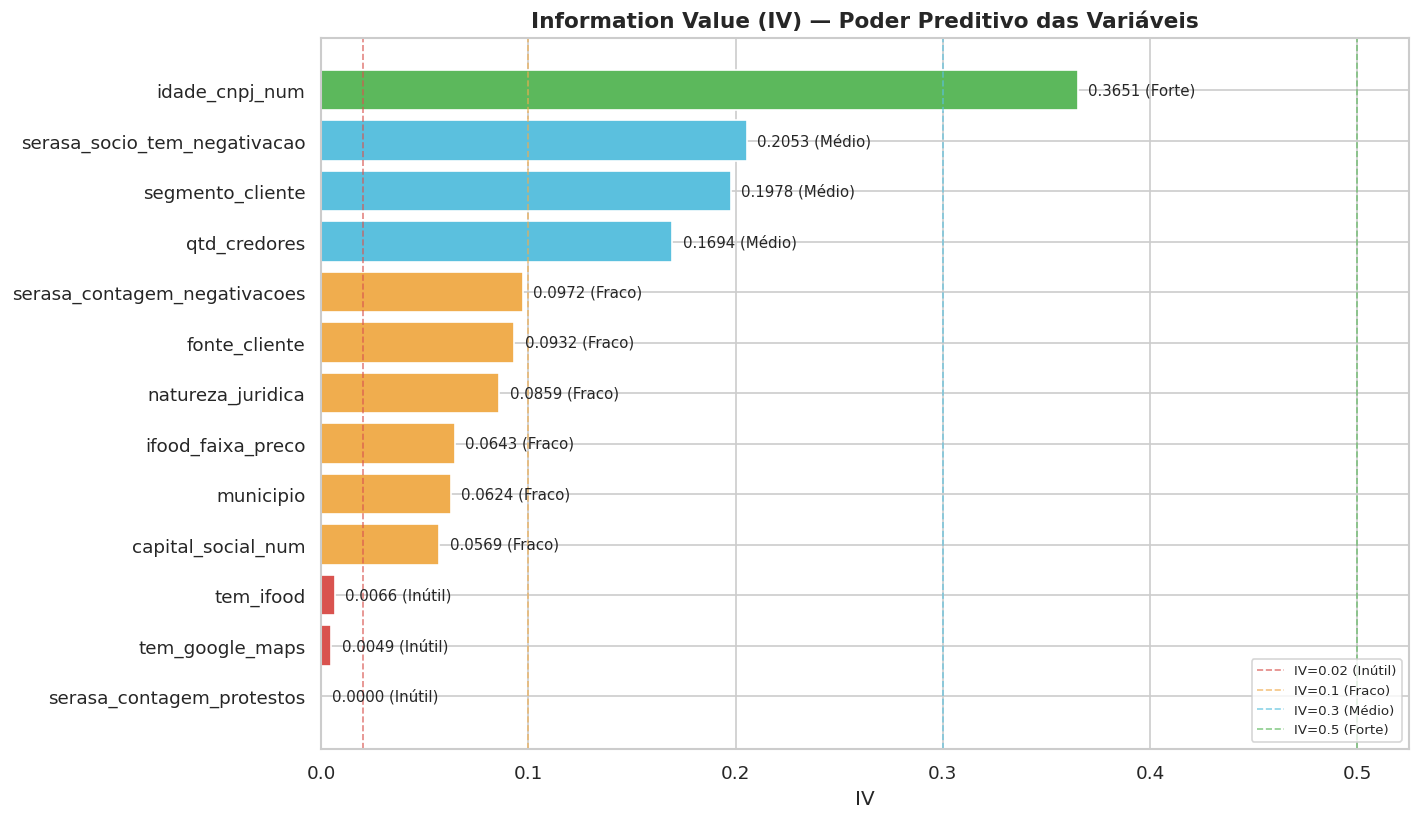

In [44]:
fig, ax = plt.subplots(figsize=(12, 7))

cores = []
for iv in df_iv["IV"]:
    if iv < 0.02:
        cores.append("#d9534f")
    elif iv < 0.10:
        cores.append("#f0ad4e")
    elif iv < 0.30:
        cores.append("#5bc0de")
    elif iv < 0.50:
        cores.append("#5cb85c")
    else:
        cores.append("#337ab7")

ax.barh(df_iv["variavel"][::-1], df_iv["IV"][::-1], color=cores[::-1], edgecolor="white")

# Linhas de referência
for x, label, cor in [(0.02, "Inútil", "#d9534f"), (0.10, "Fraco", "#f0ad4e"),
                       (0.30, "Médio", "#5bc0de"), (0.50, "Forte", "#5cb85c")]:
    ax.axvline(x=x, color=cor, linestyle="--", linewidth=1, alpha=0.7, label=f"IV={x} ({label})")

ax.set_title("Information Value (IV) — Poder Preditivo das Variáveis", fontsize=13, fontweight="bold")
ax.set_xlabel("IV")
ax.legend(loc="lower right", fontsize=8)

for i, (iv, poder) in enumerate(zip(df_iv["IV"][::-1], df_iv["poder_preditivo"][::-1])):
    ax.text(iv + 0.005, i, f"{iv:.4f} ({poder})", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/18_information_value.png",
            bbox_inches="tight")
plt.show()

## Seção 6 — Correlações e Relações entre Features

A análise de correlação busca identificar relações entre as próprias features —
não com o target. Isso é importante por dois motivos:

1. **Multicolinearidade:** features altamente correlacionadas carregam
   informação redundante. Em modelos lineares isso é problemático; em modelos
   baseados em árvores (XGBoost, Random Forest) é menos crítico mas ainda
   relevante para interpretabilidade.

2. **Agrupamento de features:** correlações altas podem sugerir que variáveis
   medem o mesmo fenômeno subjacente — ex: `serasa_contagem_negativacoes` e
   `serasa_contagem_protestos` provavelmente medem "nível de endividamento".

A análise será feita em dois grupos:
- Variáveis numéricas — matriz de correlação de Pearson
- Variáveis Serasa — correlação entre os indicadores de crédito

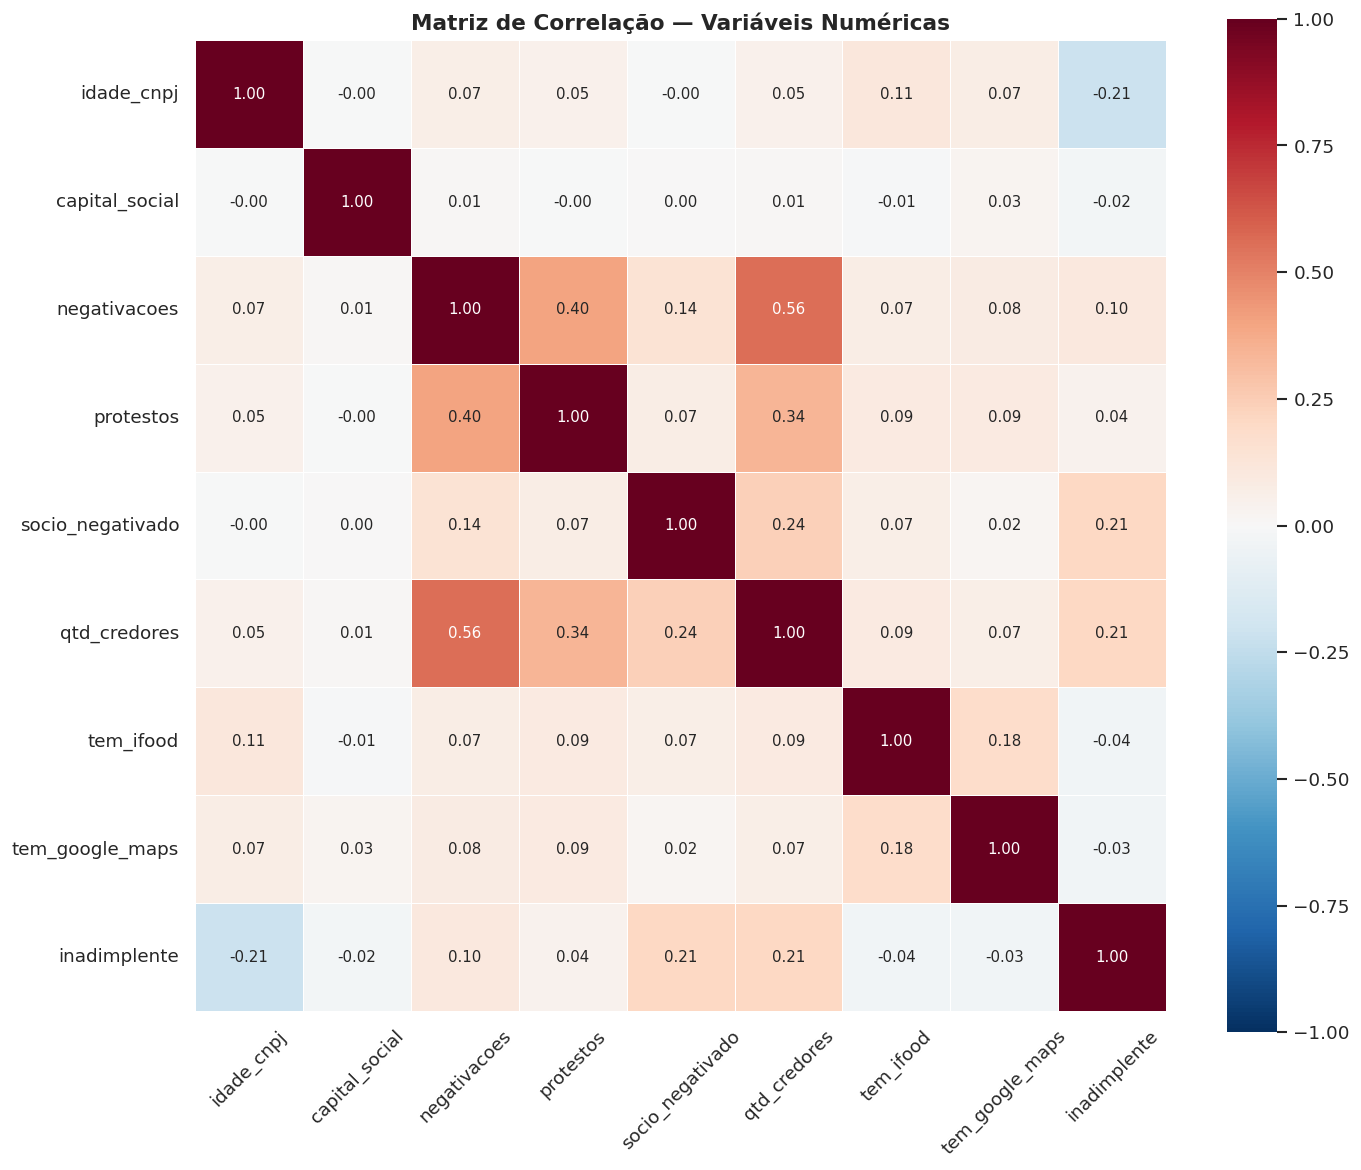

In [45]:
# Reconstruir variáveis numéricas temporárias
df["capital_social_num"] = intervalo_para_ponto_medio(df["capital_social"])
df["idade_cnpj_num"] = intervalo_para_ponto_medio(df["idade_cnpj"])
df["tem_ifood"] = df["ifood_faixa_preco"].notna().astype(float)
df["tem_google_maps"] = df["google_maps_tem_website"].notna().astype(float)
df["qtd_credores"] = df["serasa_credores"].apply(
    lambda x: 0 if pd.isnull(x) else len([c for c in str(x).split(",") if c.strip()])
)

cols_corr = [
    "idade_cnpj_num",
    "capital_social_num",
    "serasa_contagem_negativacoes",
    "serasa_contagem_protestos",
    "serasa_socio_tem_negativacao",
    "qtd_credores",
    "tem_ifood",
    "tem_google_maps",
    "inadimplente"
]

corr_matrix = df[cols_corr].corr()

# Labels mais curtos para caber no gráfico
labels = [
    "idade_cnpj",
    "capital_social",
    "negativacoes",
    "protestos",
    "socio_negativado",
    "qtd_credores",
    "tem_ifood",
    "tem_google_maps",
    "inadimplente"
]

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 9},
    xticklabels=labels,
    yticklabels=labels,
    square=True
)

ax.set_title("Matriz de Correlação — Variáveis Numéricas", fontsize=13, fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/19_correlacao_numericas.png",
            bbox_inches="tight")
plt.show()

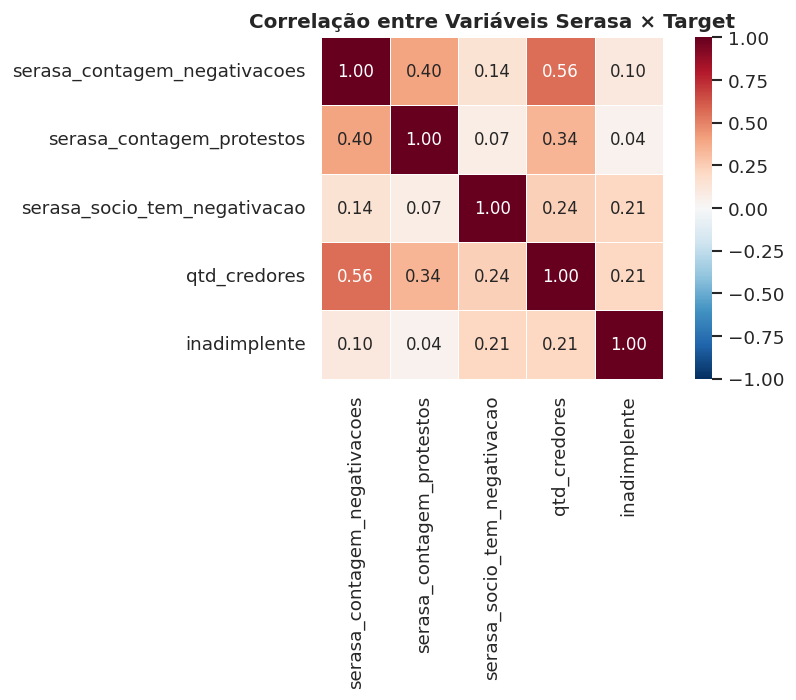

In [46]:
# Correlação entre variáveis Serasa especificamente
cols_serasa = [
    "serasa_contagem_negativacoes",
    "serasa_contagem_protestos",
    "serasa_socio_tem_negativacao",
    "qtd_credores",
    "inadimplente"
]

corr_serasa = df[cols_serasa].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_serasa,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    ax=ax,
    linewidths=0.5,
    annot_kws={"size": 10},
    square=True
)

ax.set_title("Correlação entre Variáveis Serasa × Target", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/ML_Inadimplencia_Praso/outputs/figures/20_correlacao_serasa.png",
            bbox_inches="tight")
plt.show()

# Limpar temporárias
df.drop(columns=["capital_social_num", "idade_cnpj_num",
                  "tem_ifood", "tem_google_maps", "qtd_credores"], inplace=True)

### Interpretação — Correlações entre Features

**Correlações entre variáveis Serasa:**
- `negativacoes × qtd_credores` (0,56) — correlação moderada-alta. Faz sentido:
  quem deve para mais empresas tende a acumular mais negativações. Essas
  variáveis medem aspectos diferentes do mesmo fenômeno de endividamento.
  Em modelos lineares seria um problema de multicolinearidade, mas em modelos
  baseados em árvores (XGBoost, Random Forest) ambas podem entrar sem problema.
- `negativacoes × protestos` (0,40) — correlação moderada. Protestos são
  uma forma mais grave de negativação, então é esperado que coexistam.
- `qtd_credores × protestos` (0,34) — mesma lógica: mais credores aumenta
  a probabilidade de protestos.
- `qtd_credores × socio_negativado` (0,24) — correlação fraca. Ter sócio
  negativado está associado a ter mais credores, mas são sinais distintos.

**Correlações com o target (inadimplente):**
- `idade_cnpj` (-0,21) — única correlação negativa relevante. Confirmando:
  empresas mais jovens inadimplem mais.
- `socio_negativado` (0,21) e `qtd_credores` (0,21) — correlações positivas
  iguais, ambas moderadas. Consistente com o IV calculado anteriormente.
- `negativacoes` (0,10) e `protestos` (0,04) — correlações fracas com o
  target apesar do sinal bivariado observado. Explicado pela concentração
  extrema em zero — Pearson é sensível a outliers e distribuições assimétricas.
- `capital_social` (-0,02) — praticamente zero. Consistente com o IV fraco.
- `tem_ifood` (-0,04) e `tem_google_maps` (-0,03) — correlações negativas
  muito fracas, confirmando o IV inútil das flags de presença digital.

**Correlações entre features não-Serasa:**
- `tem_ifood × tem_google_maps` (0,18) — correlação fraca. Estabelecimentos
  com presença no iFood tendem levemente a ter presença no Google Maps também,
  mas são plataformas independentes.
- `capital_social` tem correlação próxima de zero com todas as demais variáveis
  — confirma que é uma variável isolada no dataset.

**Conclusão:**
Não há multicolinearidade severa (nenhuma correlação acima de 0,60 entre
features distintas). O par mais correlacionado é `negativacoes × qtd_credores`
(0,56), que será monitorado na modelagem mas não exige remoção de nenhuma
variável. Modelos baseados em árvores são robustos a esse nível de correlação.

## Seção 7 — Insights, Decisões e Plano para o Pré-processamento

Esta seção consolida os principais achados da EDA e traduz cada um em uma
decisão concreta para o notebook `02_preprocessing.ipynb`. Cada decisão é
justificada pela evidência levantada na exploração.

---

### 7.1 — Principais Achados

**Sobre a base de dados:**
- 3.000 clientes, 100% do Ceará (CE), com 31,3% de inadimplência.
  Desbalanceamento moderado (1:2,2).
- 64,5% dos clientes em Fortaleza; os demais distribuídos em 35 municípios,
  17 deles com menos de 10 clientes.
- Perfil predominante: pequenos varejistas (75% Empresário Individual,
  mediana de capital social de R$ 9.000 e idade de CNPJ de ~3,4 anos).
- Quase metade da base (47,6%) possui sócio com negativação na Serasa,
  caracterizando um público de alto risco que dificilmente teria acesso a
  crédito tradicional.

**Sobre o poder preditivo das features (IV):**
- **Forte:** idade do CNPJ (0,3651)
- **Médio:** sócio negativado (0,2053), segmento do cliente (0,1978),
  quantidade de credores (0,1694)
- **Fraco:** negativações, fonte, natureza jurídica, faixa de preço iFood,
  município, capital social
- **Inútil:** flags de presença digital, contagem de protestos

**Sobre missing values:**
- Não são ruído — possuem significado semântico (cliente não está na
  plataforma, não tem dívida registrada).
- Imputação tradicional seria conceitualmente errada para a maioria dos casos.

---

### 7.2 — Decisões para o Pré-processamento

#### Variáveis a serem excluídas
- `id_cliente` — identificador, sem valor preditivo
- `uf` — variância zero (100% CE)
- `google_maps_tem_website` — variância zero entre os preenchidos (todos = 1)

#### Conversão de intervalos para ponto médio
Aplicar a função `intervalo_para_ponto_medio` (já desenvolvida) nas variáveis:
- `capital_social`
- `idade_cnpj`
- `ifood_contagem_avaliacoes`
- `google_maps_avaliacao`
- `google_maps_contagem_avaliacoes`

#### Tratamento de outliers (`capital_social`)
- Amplitude extrema (0,50 a 50 bilhões) com 98 clientes em 0,50 e
  20 acima de 600k.
- Aplicar transformação logarítmica `log1p` para suavizar a cauda.
- Avaliar capping no percentil 99 como alternativa.

#### Transformação logarítmica
- `capital_social_num` — distribuição extremamente assimétrica
- `idade_cnpj_num` — distribuição assimétrica à direita
- `serasa_contagem_negativacoes` — concentração extrema em zero, cauda longa
- `serasa_contagem_protestos` — mesma característica

#### Feature engineering — criar novas variáveis

**Flags de presença:**
- `tem_ifood` (1 se `ifood_faixa_preco` preenchido, 0 caso contrário)
- `tem_google_maps` (1 se `google_maps_tem_website` preenchido, 0 caso contrário)
- `tem_credores` (1 se `serasa_credores` preenchido, 0 caso contrário)

**Contagem de credores:**
- `qtd_credores` — quantidade de credores por cliente (já com forte IV de 0,1694)
- Considerar agrupar 5+ por baixa representatividade

**MultiLabelBinarizer dos segmentos de credores:**
- Criar features binárias para cada segmento com pelo menos 10 ocorrências.
- Segmentos abaixo desse limiar serão agregados em `outros_credores`.

**Decomposição hierárquica do CNAE:**
- Criar `cnae_divisao`, `cnae_grupo`, `cnae_classe`.
- Iniciar a modelagem com `cnae_divisao` (39 categorias) e avaliar se
  granularidade maior melhora o modelo.

#### Agrupamento de categorias raras

Para evitar overfitting em categorias com poucos exemplos:

| Variável | Critério proposto | Categorias afetadas |
|---|---|---|
| `fonte_cliente` | n < 30 → "outros" | Fonte 3 (n=7), Fonte 4 (n=2) |
| `natureza_juridica` | n < 30 → "outros" | EIRELI, Soc. Simples, S.A. Fechada |
| `segmento_cliente` | n < 30 → "outros" | Segmentos 12, 6, 21 e outros |
| `municipio` | Agrupar em "Fortaleza", "Reg. Metropolitana", "Interior" | 17 municípios pequenos |
| `cnae_divisao` | n < 10 → "outros" | 28 das 39 divisões |
| Segmentos de credores | freq < 10 → "outros_credores" | 18 dos 30 segmentos |

#### Encoding de variáveis categóricas
- Variáveis nominais com poucos níveis após agrupamento → **One-Hot Encoding**
  (`fonte_cliente`, `natureza_juridica`, `municipio_agrupado`, `cnae_divisao`)
- `segmento_cliente` (21 categorias originais) → **Target Encoding** com
  validação cruzada para evitar leakage, dado seu IV médio (0,1978)
- `ifood_faixa_preco` → **encoding ordinal** (1 a 5 cifrões)

#### Decisões adiadas para após o pré-processamento
- **Tratamento do desbalanceamento:** começar com `class_weight="balanced"`
  nos modelos. Avaliar SMOTE apenas se o desempenho na classe minoritária for
  insuficiente.
- **Seleção final de features:** decidir após cálculo do IV pós-transformação
  e análise de importância via SHAP nos modelos treinados.

---

### 7.3 — Divisão Treino/Teste — Cuidados Críticos

Para evitar **data leakage**, todas as decisões a seguir devem ser tomadas
**após** a separação treino/teste:

1. **Cálculo de estatísticas para imputação** (médias, medianas)
2. **Target Encoding** — fit apenas no treino, transform no teste
3. **Agrupamento de categorias raras** — decidir o que é "raro" com base no
   treino apenas
4. **Tratamento de outliers** — definir thresholds (p99) apenas no treino
5. **IV pós-transformação** — calcular apenas no treino para validação

A estratificação pelo target (`stratify=y`) é obrigatória dado o
desbalanceamento. Sugestão de divisão: 70% treino, 15% validação, 15% teste,
com `random_state=42` para reprodutibilidade.

---

### 7.4 — Próximos Passos

1. **`02_preprocessing.ipynb`:**
   - Separação treino/teste estratificada
   - Aplicar todas as decisões listadas acima
   - Recalcular IV pós-transformação
   - Salvar `df_processed` para o notebook de modelagem

2. **`03_feature_engineering.ipynb`** (opcional, pode ser unificado com o 02):
   - Construir features derivadas mais complexas
   - Validar com IV e importância via modelo baseline

3. **`04_modelagem.ipynb`:**
   - Baseline com Regressão Logística
   - Random Forest e XGBoost para captura de não-linearidades
   - Métrica principal: ROC-AUC; secundárias: PR-AUC, KS, Gini